In [1]:
import matplotlib as mpl

# Increase tick label font sizes and tick length/width globally for all plots
mpl.rcParams.update({
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "xtick.minor.size": 4,
    "ytick.minor.size": 4,
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
    "xtick.minor.width": 1.0,
    "ytick.minor.width": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
})

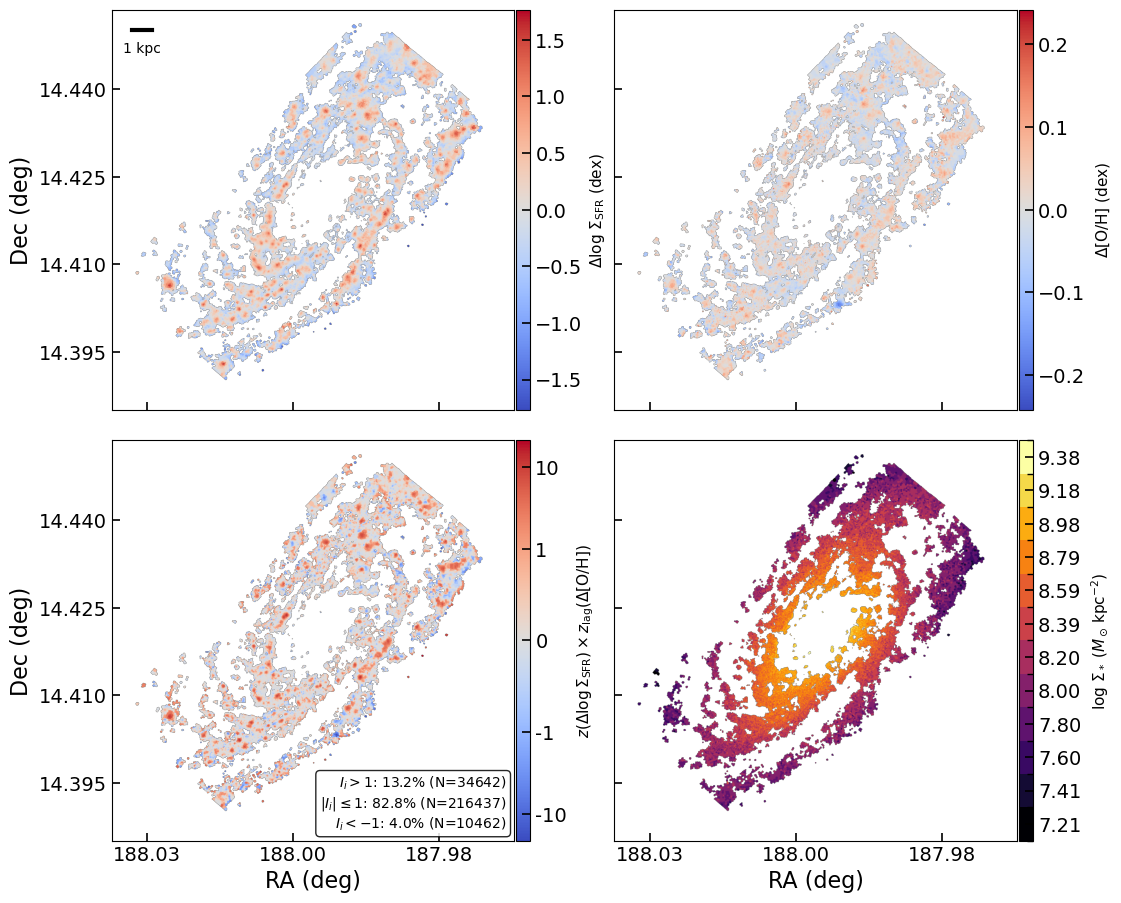

In [2]:
# ------------------------------------------------------------------
# 2x2 Combined figure: offset maps + Moran-like map + binned Σ* map
# ------------------------------------------------------------------
from pathlib import Path
from astropy.io import fits
from astropy.wcs import WCS
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gs_module
from matplotlib.colors import BoundaryNorm, SymLogNorm
import matplotlib.ticker as mticker
from matplotlib.ticker import ScalarFormatter

# Only focus on NGC4501 for this visualisation
galaxies = ['NGC4501']

# ------------------------------------------------------------------
# Define threshold parameter for linear/log colorbar transition and classification
# ------------------------------------------------------------------
threshold = 1  # Values between -threshold and +threshold use linear scale

# ------------------------------------------------------------------
# 1.  Helper: read the required maps
# ------------------------------------------------------------------
def load_maps(gal):
    spatial_path = f'{gal}_SPATIAL_BINNING_maps_extended.fits'
    gas_path = f'{gal}_gas_BIN_maps_extended.fits'

    if not (Path(spatial_path).exists() and Path(gas_path).exists()):
        raise FileNotFoundError(f'Required FITS files for {gal} not found.')

    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
        wcs = WCS(h_spatial['LOGMASS_SURFACE_DENSITY'].header)
    with fits.open(gas_path) as h_gas:
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
        if 'O_H_O3N2_M14_HII' in h_gas:
            oh_map = h_gas['O_H_O3N2_M14_HII'].data
            indicator_name = 'O3N2-M14'
        elif 'O_H_O3N2_M13_HII' in h_gas:
            print(f"Warning: O3N2-M14 not available for {gal}; using O3N2-M13 instead.")
            oh_map = h_gas['O_H_O3N2_M13_HII'].data
            indicator_name = 'O3N2-M13'
        else:
            available = [hdu.name for hdu in h_gas]
            raise KeyError(f"No O3N2 metallicity extension (M14/M13) found for {gal}. Available: {available}")
        gas_header = h_gas['LOGSFR_SURFACE_DENSITY_HII'].header
    return sigM, sigSFR, oh_map, indicator_name, wcs, gas_header

for gal in galaxies:
    sigM, sigSFR, oh_o3n2_map, indicator_name, wcs_full, gas_header = load_maps(gal)

    # Valid pixels across maps
    valid_sfr = np.isfinite(sigSFR)
    valid_oh = np.isfinite(oh_o3n2_map)
    valid_sigM = np.isfinite(sigM)
    valid_all = valid_sfr & valid_oh & valid_sigM

    # ------------------------------------------------------------------
    # 2.  Calculate offset maps (relative to Σ* bin means)
    # ------------------------------------------------------------------
    # Define 12 Σ* bins
    n_bins = 12
    sigmaM_min = np.nanmin(sigM[valid_all])
    sigmaM_max = np.nanmax(sigM[valid_all])
    sigmaM_bin_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins + 1)
    
    # Initialize offset maps
    sfr_offset = np.full_like(sigSFR, np.nan)
    oh_offset = np.full_like(oh_o3n2_map, np.nan)
    
    # Calculate offset for each Σ* bin
    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
        else:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        
        if np.sum(bin_mask) > 0:
            # Calculate bin mean and offset within this bin
            sfr_bin_mean = np.mean(sigSFR[bin_mask])
            oh_bin_mean = np.mean(oh_o3n2_map[bin_mask])
            
            sfr_offset[bin_mask] = sigSFR[bin_mask] - sfr_bin_mean
            oh_offset[bin_mask] = oh_o3n2_map[bin_mask] - oh_bin_mean
    
    sfr_offset_max = np.nanmax(np.abs(sfr_offset[valid_all]))
    oh_offset_max = np.nanmax(np.abs(oh_offset[valid_all]))
    
    # Global means for display purposes only
    sfr_mean = np.nanmean(sigSFR[valid_sfr])
    oh_mean = np.nanmean(oh_o3n2_map[valid_oh])

    # ------------------------------------------------------------------
    # 3.  Calculate local bivariate Moran-like map
    # ------------------------------------------------------------------
    def local_bivariate_moran(A, B, valid_mask, neighbourhood='queen'):
        """
        Simple Moran-style local bivariate association between A and B.

        Parameters
        ----------
        A, B : 2D arrays
            Maps (e.g. sfr_offset, oh_offset).
        valid_mask : 2D bool
            True where both maps are valid.
        neighbourhood : {'queen', 'rook'}
            'queen' = 8-connected neighbours, 'rook' = 4-connected.

        Returns
        -------
        I_map : 2D array
            Local bivariate Moran-like statistic (sign & amplitude).
        quad_map : 2D int array
            Quadrant type:
            0 = invalid / no neighbours
            1 = high A, high lag(B)
            2 = low A,  high lag(B)
            3 = low A,  low lag(B)
            4 = high A, low lag(B)
        """
        ny, nx = A.shape
        I_map = np.full_like(A, np.nan, dtype=float)
        quad_map = np.zeros_like(A, dtype=int)

        # standardise A,B on valid pixels only
        Aval = A[valid_mask]
        Bval = B[valid_mask]
        Az = (A - np.nanmean(Aval)) / np.nanstd(Aval)
        Bz = (B - np.nanmean(Bval)) / np.nanstd(Bval)

        if neighbourhood == 'queen':
            offsets = [(-1,-1), (-1,0), (-1,1),
                       ( 0,-1),          ( 0,1),
                       ( 1,-1), ( 1,0), ( 1,1)]
        elif neighbourhood == 'rook':
            offsets = [(-1,0), (0,-1), (0,1), (1,0)]
        else:
            raise ValueError("neighbourhood must be 'queen' or 'rook'")

        for i in range(ny):
            for j in range(nx):
                if not valid_mask[i, j]:
                    continue

                # collect neighbouring Bz values
                neigh_vals = []
                for dy, dx in offsets:
                    ii, jj = i + dy, j + dx
                    if 0 <= ii < ny and 0 <= jj < nx and valid_mask[ii, jj]:
                        neigh_vals.append(Bz[ii, jj])

                if len(neigh_vals) == 0:
                    continue

                lag_B = np.mean(neigh_vals)   # spatial lag of B
                I_val = Az[i, j] * lag_B      # Moran-style product
                I_map[i, j] = I_val

                # quadrant classification (like LISA maps)
                if Az[i, j] >= 0 and lag_B >= 0:
                    quad_map[i, j] = 1  # high A – high B_neigh
                elif Az[i, j] < 0 and lag_B >= 0:
                    quad_map[i, j] = 2  # low A – high B_neigh
                elif Az[i, j] < 0 and lag_B < 0:
                    quad_map[i, j] = 3  # low A – low B_neigh
                else:
                    quad_map[i, j] = 4  # high A – low B_neigh

        return I_map, quad_map

    I_map, quad_map = local_bivariate_moran(sfr_offset, oh_offset, valid_all,
                                            neighbourhood='queen')

    # ------------------------------------------------------------------
    # Calculate statistics for three classes based on threshold
    # ------------------------------------------------------------------
    valid_I = np.isfinite(I_map)
    n_total = np.sum(valid_I)
    n_high = np.sum(I_map[valid_I] > threshold)
    n_mid = np.sum((I_map[valid_I] >= -threshold) & (I_map[valid_I] <= threshold))
    n_low = np.sum(I_map[valid_I] < -threshold)
    pct_high = (n_high / n_total * 100) if n_total > 0 else 0
    pct_mid = (n_mid / n_total * 100) if n_total > 0 else 0
    pct_low = (n_low / n_total * 100) if n_total > 0 else 0

    # ------------------------------------------------------------------
    # 4.  Create binned Σ* map
    # ------------------------------------------------------------------
    sigM_binned_map = np.full_like(sigM, np.nan)
    
    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
        else:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        
        # Assign bin center value
        bin_center = (sigmaM_bin_edges[i] + sigmaM_bin_edges[i+1]) / 2
        sigM_binned_map[bin_mask] = bin_center

    # ------------------------------------------------------------------
    # 5.  Prepare coordinate extent
    # ------------------------------------------------------------------
    wcs_celestial = WCS(gas_header).celestial
    y_size, x_size = sigSFR.shape
    x_coords = np.arange(x_size)
    y_coords = np.arange(y_size)
    xx, yy = np.meshgrid(x_coords, y_coords)
    ra, dec = wcs_celestial.pixel_to_world_values(xx, yy)
    extent = [ra.max(), ra.min(), dec.min(), dec.max()]

    # ------------------------------------------------------------------
    # 5b.  Scale bar: 1 kpc for 0.2 arcsec/pixel at 16.5 Mpc
    # ------------------------------------------------------------------
    pix_scale_arcsec = 0.2
    distance_mpc = 16.5
    kpc_arcsec = 206265.0 / (distance_mpc * 1000.0)
    scalebar_length_deg = kpc_arcsec / 3600.0

    def add_scalebar(ax, length_deg, label='1 kpc'):
        x0, x1 = ax.get_xlim()
        x_range = abs(x1 - x0)
        if x_range == 0:
            return
        frac_len = length_deg / x_range
        x_start = 0.05
        y_start = 0.95
        x_end = x_start + frac_len
        line, = ax.plot([x_start, x_end], [y_start, y_start], transform=ax.transAxes,
                        color='k', lw=3, clip_on=False)
        line.set_in_layout(False)
        txt = ax.text((x_start + x_end) / 2, y_start - 0.03, label,
                      transform=ax.transAxes, ha='center', va='top', color='k')
        txt.set_in_layout(False)

    # ------------------------------------------------------------------
    # 6.  2x2 figure: shared axes, equal aspect preserved, colorbars glued to axes
    # ------------------------------------------------------------------
    from mpl_toolkits.axes_grid1 import make_axes_locatable

    # Auto-derive a reasonable figsize from the map extent
    dx = abs(extent[1] - extent[0])   # RA span
    dy = abs(extent[3] - extent[2])   # Dec span
    data_ratio = (dx / dy) if dy > 0 else 1.0  # width / height

    panel_h = 4.2   # inches per panel height (tune once)
    panel_w = panel_h * data_ratio
    cbar_w = 0.35   # inches per colorbar (tune once)

    W = 2 * panel_w + 2 * cbar_w + 1.2
    H = 2 * panel_h + 0.8

    fig, axs = plt.subplots(
        2, 2, figsize=(W, H), sharex=True, sharey=True
    )

    # Make space for the appended colorbars (right margin matters)
    fig.subplots_adjust(
        left=0.07, right=0.96, bottom=0.07, top=0.98,
        wspace=0.20, hspace=0.06
    )

    ax1, ax2 = axs[0, 0], axs[0, 1]
    ax3, ax4 = axs[1, 0], axs[1, 1]

    def add_cbar(ax, im, label, size="3.5%", pad=0.02, labelpad=6, labelsize=11):
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size=size, pad=pad)
        cbar = fig.colorbar(im, cax=cax)
        cbar.set_label(label, fontsize=labelsize, labelpad=labelpad)
        return cbar

    # --- Ticks / formatting (readable RA, no +1.834e2)
    for ax in (ax1, ax2, ax3, ax4):
        ax.xaxis.set_major_locator(mticker.MaxNLocator(3))
        ax.yaxis.set_major_locator(mticker.MaxNLocator(5))
        ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

    # Hide inner tick labels
    plt.setp(ax1.get_xticklabels(), visible=False)
    plt.setp(ax2.get_xticklabels(), visible=False)
    plt.setp(ax2.get_yticklabels(), visible=False)
    plt.setp(ax4.get_yticklabels(), visible=False)

    # Axis labels (outer only)
    ax3.set_xlabel("RA (deg)", fontsize=16)
    ax4.set_xlabel("RA (deg)", fontsize=16)
    ax1.set_ylabel("Dec (deg)", fontsize=16)
    ax3.set_ylabel("Dec (deg)", fontsize=16)

    # ---- Panel 1: SFR offset
    im_sfr = ax1.imshow(
        np.ma.masked_invalid(sfr_offset),
        origin="lower", cmap="coolwarm",
        extent=extent, vmin=-sfr_offset_max, vmax=sfr_offset_max,
        aspect="equal"
    )
    add_scalebar(ax1, scalebar_length_deg, label="1 kpc")
    add_cbar(ax1, im_sfr, r'$\Delta\log\,\Sigma_{\mathrm{SFR}}$ (dex)', labelpad=4)

    # ---- Panel 2: OH offset
    im_oh = ax2.imshow(
        np.ma.masked_invalid(oh_offset),
        origin="lower", cmap="coolwarm",
        extent=extent, vmin=-oh_offset_max, vmax=oh_offset_max,
        aspect="equal"
    )
    add_cbar(ax2, im_oh, r'$\Delta$[O/H] (dex)')

    # ---- Panel 3: Moran-like
    vI = np.nanmax(np.abs(I_map))
    norm = SymLogNorm(linthresh=threshold, linscale=1.0, vmin=-vI, vmax=vI, base=10)

    imI = ax3.imshow(
        np.ma.masked_invalid(I_map),
        origin="lower", cmap="coolwarm",
        extent=extent, norm=norm,
        aspect="equal"
    )
    cbarI = add_cbar(
        ax3, imI,
        r'$z(\Delta\log\Sigma_{\rm SFR}) \times z_{\rm lag}(\Delta{\rm [O/H]})$'
    )

    # Keep your symmetric-log ticks logic
    max_pow = int(np.floor(np.log10(vI))) if vI > 0 else 0
    pos_ticks = [10**k for k in range(0, max_pow + 1) if 10**k <= vI]
    pos_ticks_filtered = [p for p in pos_ticks if p != threshold]
    neg_ticks_filtered = [-p for p in reversed(pos_ticks_filtered)]
    ticks = sorted(set(neg_ticks_filtered + [-threshold, 0.0, threshold] + pos_ticks_filtered))
    cbarI.set_ticks(ticks)
    cbarI.set_ticklabels([f"{t:g}" for t in ticks])

    legend_text = (
        rf'$I_i > {threshold}$: {pct_high:.1f}% (N={n_high})'
        '\n' + rf'$|I_i| \leq {threshold}$: {pct_mid:.1f}% (N={n_mid})'
        '\n' + rf'$I_i < -{threshold}$: {pct_low:.1f}% (N={n_low})'
    )
    ax3.text(
        0.98, 0.02, legend_text, transform=ax3.transAxes,
        fontsize=10, va="bottom", ha="right",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.85)
    )

    # ---- Panel 4: binned Σ*
    cmap_discrete = plt.cm.inferno
    norm_discrete = BoundaryNorm(sigmaM_bin_edges, cmap_discrete.N)

    im_sigM_binned = ax4.imshow(
        np.ma.masked_invalid(sigM_binned_map),
        origin="lower", cmap=cmap_discrete, norm=norm_discrete,
        extent=extent,
        aspect="equal"
    )
    cbar_binned = add_cbar(
        ax4, im_sigM_binned,
        r'$\log\,\Sigma_*\;(M_\odot\,\mathrm{kpc}^{-2})$'
    )

    bin_centers = [(sigmaM_bin_edges[i] + sigmaM_bin_edges[i+1]) / 2 for i in range(n_bins)]
    cbar_binned.set_ticks(bin_centers)
    cbar_binned.set_ticklabels([f"{bc:.2f}" for bc in bin_centers])

    # fig.savefig(f'Plot_Paper_1/{gal}_correlation_map_moran.png', dpi=600, bbox_inches="tight", pad_inches=0.02)
    # fig.savefig(f'Plot_Paper_1/{gal}_correlation_map_moran.pdf', bbox_inches="tight", pad_inches=0.02)
    plt.show()

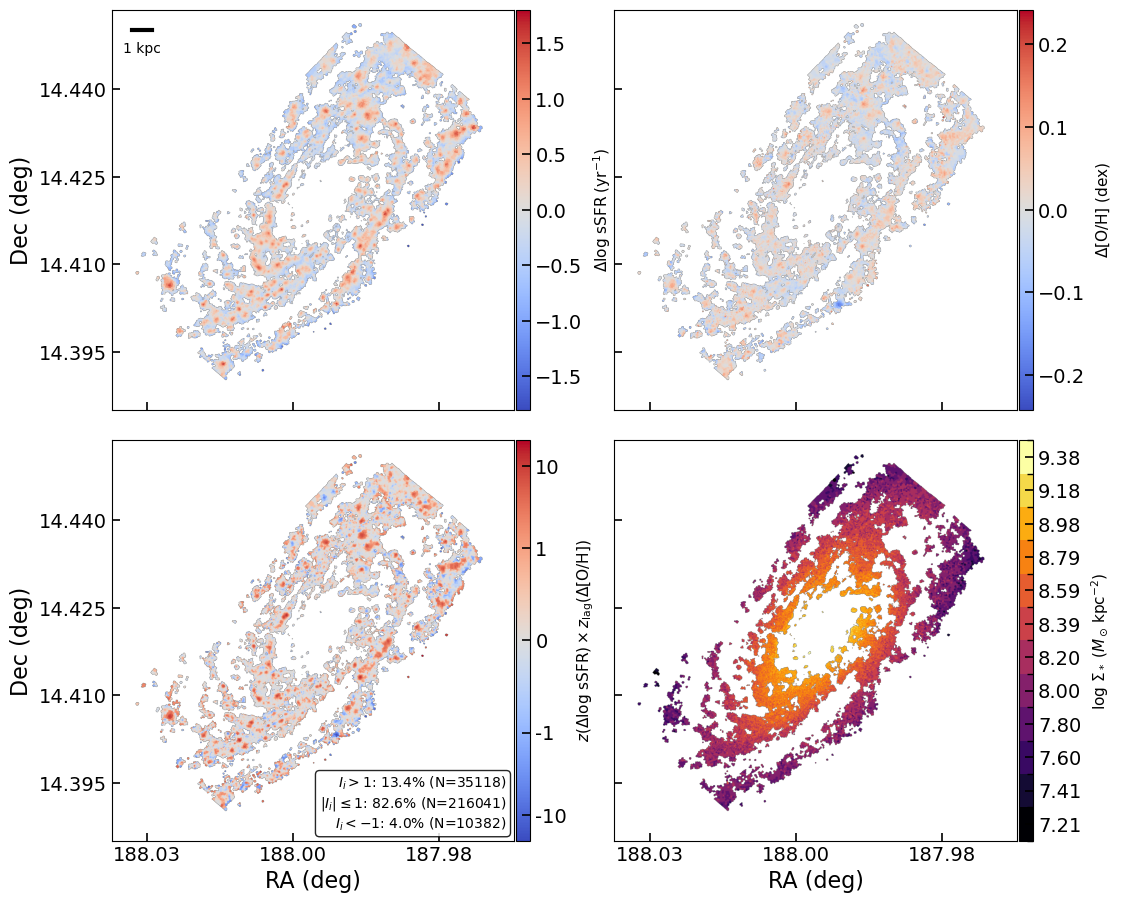

In [3]:
# ------------------------------------------------------------------
# 2x2 Combined figure: sSFR offset maps + Moran-like map + binned Σ* map
# ------------------------------------------------------------------
from pathlib import Path
from astropy.io import fits
from astropy.wcs import WCS
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gs_module
from matplotlib.colors import BoundaryNorm, SymLogNorm
import matplotlib.ticker as mticker
from matplotlib.ticker import ScalarFormatter

# Only focus on NGC4501 for this visualisation
galaxies = ['NGC4501']

# ------------------------------------------------------------------
# Define threshold parameter for linear/log colorbar transition and classification
# ------------------------------------------------------------------
threshold = 1  # Values between -threshold and +threshold use linear scale

# ------------------------------------------------------------------
# 1.  Helper: read the required maps
# ------------------------------------------------------------------
def load_maps(gal):
    spatial_path = f'{gal}_SPATIAL_BINNING_maps_extended.fits'
    gas_path = f'{gal}_gas_BIN_maps_extended.fits'

    if not (Path(spatial_path).exists() and Path(gas_path).exists()):
        raise FileNotFoundError(f'Required FITS files for {gal} not found.')

    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
        wcs = WCS(h_spatial['LOGMASS_SURFACE_DENSITY'].header)
    with fits.open(gas_path) as h_gas:
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
        if 'O_H_O3N2_M14_HII' in h_gas:
            oh_map = h_gas['O_H_O3N2_M14_HII'].data
            indicator_name = 'O3N2-M14'
        elif 'O_H_O3N2_M13_HII' in h_gas:
            print(f"Warning: O3N2-M14 not available for {gal}; using O3N2-M13 instead.")
            oh_map = h_gas['O_H_O3N2_M13_HII'].data
            indicator_name = 'O3N2-M13'
        else:
            available = [hdu.name for hdu in h_gas]
            raise KeyError(f"No O3N2 metallicity extension (M14/M13) found for {gal}. Available: {available}")
        gas_header = h_gas['LOGSFR_SURFACE_DENSITY_HII'].header
    return sigM, sigSFR, oh_map, indicator_name, wcs, gas_header

for gal in galaxies:
    sigM, sigSFR, oh_o3n2_map, indicator_name, wcs_full, gas_header = load_maps(gal)

    # Construct log(sSFR) map from log(SFR surface density) and log(stellar mass surface density)
    ssfr = sigSFR - sigM

    # Valid pixels across maps
    valid_ssfr = np.isfinite(ssfr)
    valid_oh = np.isfinite(oh_o3n2_map)
    valid_sigM = np.isfinite(sigM)
    valid_all = valid_ssfr & valid_oh & valid_sigM

    # ------------------------------------------------------------------
    # 2.  Calculate offset maps (relative to Σ* bin means)
    # ------------------------------------------------------------------
    # Define 12 Σ* bins
    n_bins = 12
    sigmaM_min = np.nanmin(sigM[valid_all])
    sigmaM_max = np.nanmax(sigM[valid_all])
    sigmaM_bin_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins + 1)
    
    # Initialize offset maps
    ssfr_offset = np.full_like(ssfr, np.nan)
    oh_offset = np.full_like(oh_o3n2_map, np.nan)
    
    # Calculate offset for each Σ* bin
    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
        else:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        
        if np.sum(bin_mask) > 0:
            # Calculate bin mean and offset within this bin
            ssfr_bin_mean = np.mean(ssfr[bin_mask])
            oh_bin_mean = np.mean(oh_o3n2_map[bin_mask])
            
            ssfr_offset[bin_mask] = ssfr[bin_mask] - ssfr_bin_mean
            oh_offset[bin_mask] = oh_o3n2_map[bin_mask] - oh_bin_mean
    
    ssfr_offset_max = np.nanmax(np.abs(ssfr_offset[valid_all]))
    oh_offset_max = np.nanmax(np.abs(oh_offset[valid_all]))
    
    # Global means for display purposes only
    ssfr_mean = np.nanmean(ssfr[valid_ssfr])
    oh_mean = np.nanmean(oh_o3n2_map[valid_oh])

    # ------------------------------------------------------------------
    # 3.  Calculate local bivariate Moran-like map
    # ------------------------------------------------------------------
    def local_bivariate_moran(A, B, valid_mask, neighbourhood='queen'):
        """
        Simple Moran-style local bivariate association between A and B.

        Parameters
        ----------
        A, B : 2D arrays
            Maps (e.g. ssfr_offset, oh_offset).
        valid_mask : 2D bool
            True where both maps are valid.
        neighbourhood : {'queen', 'rook'}
            'queen' = 8-connected neighbours, 'rook' = 4-connected.

        Returns
        -------
        I_map : 2D array
            Local bivariate Moran-like statistic (sign & amplitude).
        quad_map : 2D int array
            Quadrant type:
            0 = invalid / no neighbours
            1 = high A, high lag(B)
            2 = low A,  high lag(B)
            3 = low A,  low lag(B)
            4 = high A, low lag(B)
        """
        ny, nx = A.shape
        I_map = np.full_like(A, np.nan, dtype=float)
        quad_map = np.zeros_like(A, dtype=int)

        # standardise A,B on valid pixels only
        Aval = A[valid_mask]
        Bval = B[valid_mask]
        Az = (A - np.nanmean(Aval)) / np.nanstd(Aval)
        Bz = (B - np.nanmean(Bval)) / np.nanstd(Bval)

        if neighbourhood == 'queen':
            offsets = [(-1,-1), (-1,0), (-1,1),
                       ( 0,-1),          ( 0,1),
                       ( 1,-1), ( 1,0), ( 1,1)]
        elif neighbourhood == 'rook':
            offsets = [(-1,0), (0,-1), (0,1), (1,0)]
        else:
            raise ValueError("neighbourhood must be 'queen' or 'rook'")

        for i in range(ny):
            for j in range(nx):
                if not valid_mask[i, j]:
                    continue

                # collect neighbouring Bz values
                neigh_vals = []
                for dy, dx in offsets:
                    ii, jj = i + dy, j + dx
                    if 0 <= ii < ny and 0 <= jj < nx and valid_mask[ii, jj]:
                        neigh_vals.append(Bz[ii, jj])

                if len(neigh_vals) == 0:
                    continue

                lag_B = np.mean(neigh_vals)   # spatial lag of B
                I_val = Az[i, j] * lag_B      # Moran-style product
                I_map[i, j] = I_val

                # quadrant classification (like LISA maps)
                if Az[i, j] >= 0 and lag_B >= 0:
                    quad_map[i, j] = 1  # high A – high B_neigh
                elif Az[i, j] < 0 and lag_B >= 0:
                    quad_map[i, j] = 2  # low A – high B_neigh
                elif Az[i, j] < 0 and lag_B < 0:
                    quad_map[i, j] = 3  # low A – low B_neigh
                else:
                    quad_map[i, j] = 4  # high A – low B_neigh

        return I_map, quad_map

    I_map, quad_map = local_bivariate_moran(ssfr_offset, oh_offset, valid_all,
                                            neighbourhood='queen')

    # ------------------------------------------------------------------
    # Calculate statistics for three classes based on threshold
    # ------------------------------------------------------------------
    valid_I = np.isfinite(I_map)
    n_total = np.sum(valid_I)
    n_high = np.sum(I_map[valid_I] > threshold)
    n_mid = np.sum((I_map[valid_I] >= -threshold) & (I_map[valid_I] <= threshold))
    n_low = np.sum(I_map[valid_I] < -threshold)
    pct_high = (n_high / n_total * 100) if n_total > 0 else 0
    pct_mid = (n_mid / n_total * 100) if n_total > 0 else 0
    pct_low = (n_low / n_total * 100) if n_total > 0 else 0

    # ------------------------------------------------------------------
    # 4.  Create binned Σ* map
    # ------------------------------------------------------------------
    sigM_binned_map = np.full_like(sigM, np.nan)
    
    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
        else:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        
        # Assign bin center value
        bin_center = (sigmaM_bin_edges[i] + sigmaM_bin_edges[i+1]) / 2
        sigM_binned_map[bin_mask] = bin_center

    # ------------------------------------------------------------------
    # 5.  Prepare coordinate extent
    # ------------------------------------------------------------------
    wcs_celestial = WCS(gas_header).celestial
    y_size, x_size = sigSFR.shape
    x_coords = np.arange(x_size)
    y_coords = np.arange(y_size)
    xx, yy = np.meshgrid(x_coords, y_coords)
    ra, dec = wcs_celestial.pixel_to_world_values(xx, yy)
    extent = [ra.max(), ra.min(), dec.min(), dec.max()]

    # ------------------------------------------------------------------
    # 5b.  Scale bar: 1 kpc for 0.2 arcsec/pixel at 16.5 Mpc
    # ------------------------------------------------------------------
    pix_scale_arcsec = 0.2
    distance_mpc = 16.5
    kpc_arcsec = 206265.0 / (distance_mpc * 1000.0)
    scalebar_length_deg = kpc_arcsec / 3600.0

    def add_scalebar(ax, length_deg, label='1 kpc'):
        x0, x1 = ax.get_xlim()
        x_range = abs(x1 - x0)
        if x_range == 0:
            return
        frac_len = length_deg / x_range
        x_start = 0.05
        y_start = 0.95
        x_end = x_start + frac_len
        line, = ax.plot([x_start, x_end], [y_start, y_start], transform=ax.transAxes,
                        color='k', lw=3, clip_on=False)
        line.set_in_layout(False)
        txt = ax.text((x_start + x_end) / 2, y_start - 0.03, label,
                      transform=ax.transAxes, ha='center', va='top', color='k')
        txt.set_in_layout(False)

    # ------------------------------------------------------------------
    # 6.  2x2 figure: shared axes, equal aspect preserved, colorbars glued to axes
    # ------------------------------------------------------------------
    from mpl_toolkits.axes_grid1 import make_axes_locatable

    # Auto-derive a reasonable figsize from the map extent
    dx = abs(extent[1] - extent[0])   # RA span
    dy = abs(extent[3] - extent[2])   # Dec span
    data_ratio = (dx / dy) if dy > 0 else 1.0  # width / height

    panel_h = 4.2   # inches per panel height (tune once)
    panel_w = panel_h * data_ratio
    cbar_w = 0.35   # inches per colorbar (tune once)

    W = 2 * panel_w + 2 * cbar_w + 1.2
    H = 2 * panel_h + 0.8

    fig, axs = plt.subplots(
        2, 2, figsize=(W, H), sharex=True, sharey=True
    )

    # Make space for the appended colorbars (right margin matters)
    fig.subplots_adjust(
        left=0.07, right=0.96, bottom=0.07, top=0.98,
        wspace=0.20, hspace=0.06
    )

    ax1, ax2 = axs[0, 0], axs[0, 1]
    ax3, ax4 = axs[1, 0], axs[1, 1]

    def add_cbar(ax, im, label, size="3.5%", pad=0.02, labelpad=6, labelsize=11):
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size=size, pad=pad)
        cbar = fig.colorbar(im, cax=cax)
        cbar.set_label(label, fontsize=labelsize, labelpad=labelpad)
        return cbar

    # --- Ticks / formatting (readable RA, no +1.834e2)
    for ax in (ax1, ax2, ax3, ax4):
        ax.xaxis.set_major_locator(mticker.MaxNLocator(3))
        ax.yaxis.set_major_locator(mticker.MaxNLocator(5))
        ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

    # Hide inner tick labels
    plt.setp(ax1.get_xticklabels(), visible=False)
    plt.setp(ax2.get_xticklabels(), visible=False)
    plt.setp(ax2.get_yticklabels(), visible=False)
    plt.setp(ax4.get_yticklabels(), visible=False)

    # Axis labels (outer only)
    ax3.set_xlabel("RA (deg)", fontsize=16)
    ax4.set_xlabel("RA (deg)", fontsize=16)
    ax1.set_ylabel("Dec (deg)", fontsize=16)
    ax3.set_ylabel("Dec (deg)", fontsize=16)

    # ---- Panel 1: sSFR offset
    im_ssfr = ax1.imshow(
        np.ma.masked_invalid(ssfr_offset),
        origin="lower", cmap="coolwarm",
        extent=extent, vmin=-ssfr_offset_max, vmax=ssfr_offset_max,
        aspect="equal"
    )
    add_scalebar(ax1, scalebar_length_deg, label="1 kpc")
    add_cbar(ax1, im_ssfr, r'$\Delta\log\,\mathrm{sSFR}\;(\mathrm{yr}^{-1})$')

    # ---- Panel 2: OH offset
    im_oh = ax2.imshow(
        np.ma.masked_invalid(oh_offset),
        origin="lower", cmap="coolwarm",
        extent=extent, vmin=-oh_offset_max, vmax=oh_offset_max,
        aspect="equal"
    )
    add_cbar(ax2, im_oh, r'$\Delta$[O/H] (dex)')

    # ---- Panel 3: Moran-like
    vI = np.nanmax(np.abs(I_map))
    norm = SymLogNorm(linthresh=threshold, linscale=1.0, vmin=-vI, vmax=vI, base=10)

    imI = ax3.imshow(
        np.ma.masked_invalid(I_map),
        origin="lower", cmap="coolwarm",
        extent=extent, norm=norm,
        aspect="equal"
    )
    cbarI = add_cbar(
        ax3, imI,
        r'$z(\Delta\log\,\mathrm{sSFR}) \times z_{\rm lag}(\Delta{\rm [O/H]})$'
    )

    # Keep your symmetric-log ticks logic
    max_pow = int(np.floor(np.log10(vI))) if vI > 0 else 0
    pos_ticks = [10**k for k in range(0, max_pow + 1) if 10**k <= vI]
    pos_ticks_filtered = [p for p in pos_ticks if p != threshold]
    neg_ticks_filtered = [-p for p in reversed(pos_ticks_filtered)]
    ticks = sorted(set(neg_ticks_filtered + [-threshold, 0.0, threshold] + pos_ticks_filtered))
    cbarI.set_ticks(ticks)
    cbarI.set_ticklabels([f"{t:g}" for t in ticks])

    legend_text = (
        rf'$I_i > {threshold}$: {pct_high:.1f}% (N={n_high})'
        '\n' + rf'$|I_i| \leq {threshold}$: {pct_mid:.1f}% (N={n_mid})'
        '\n' + rf'$I_i < -{threshold}$: {pct_low:.1f}% (N={n_low})'
    )
    ax3.text(
        0.98, 0.02, legend_text, transform=ax3.transAxes,
        fontsize=10, va="bottom", ha="right",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.85)
    )

    # ---- Panel 4: binned Σ*
    cmap_discrete = plt.cm.inferno
    norm_discrete = BoundaryNorm(sigmaM_bin_edges, cmap_discrete.N)

    im_sigM_binned = ax4.imshow(
        np.ma.masked_invalid(sigM_binned_map),
        origin="lower", cmap=cmap_discrete, norm=norm_discrete,
        extent=extent,
        aspect="equal"
    )
    cbar_binned = add_cbar(
        ax4, im_sigM_binned,
        r'$\log\,\Sigma_*\;(M_\odot\,\mathrm{kpc}^{-2})$'
    )

    bin_centers = [(sigmaM_bin_edges[i] + sigmaM_bin_edges[i+1]) / 2 for i in range(n_bins)]
    cbar_binned.set_ticks(bin_centers)
    cbar_binned.set_ticklabels([f"{bc:.2f}" for bc in bin_centers])

    # fig.savefig(f'Plot_Paper_1/{gal}_correlation_map_moran.png', dpi=600, bbox_inches="tight", pad_inches=0.02)
    # fig.savefig(f'Plot_Paper_1/{gal}_correlation_map_moran.pdf', bbox_inches="tight", pad_inches=0.02)
    plt.show()

STEP 1: Collecting data from all galaxies for HII regions (O3N2-M13 only)...
  IC3392: HII=14906 pixels
  NGC4064: HII=7077 pixels
  NGC4192: HII=146165 pixels
  NGC4293: HII=5715 pixels
  NGC4298: HII=156571 pixels
  NGC4330: HII=43026 pixels
  NGC4383: excluded from analysis
  NGC4396: HII=81745 pixels
  NGC4419: HII=7386 pixels
  NGC4457: HII=6355 pixels
  NGC4501: HII=261541 pixels
  NGC4522: HII=39619 pixels
  NGC4694: HII=2586 pixels
  NGC4698: HII=10181 pixels

Total combined pixels (HII): 782873

STEP 2: Defining 8 SFR bins for rMZR
  Bin 1: <-3.5
  Bin 2: -3.5–-3.0
  Bin 3: -3.0–-2.5
  Bin 4: -2.5–-2.0
  Bin 5: -2.0–-1.5
  Bin 6: -1.5–-1.0
  Bin 7: -1.0–-0.5
  Bin 8: >-0.5

STEP 3: Defining 8 Σ_* bins for Z_gas-Σ_SFR
  Bin 1: <6.5
  Bin 2: 6.5–7.0
  Bin 3: 7.0–7.5
  Bin 4: 7.5–8.0
  Bin 5: 8.0–8.5
  Bin 6: 8.5–9.0
  Bin 7: 9.0–9.5
  Bin 8: >9.5

STEP 4: Creating combined 2x2 plot (O3N2-M13 only)

Using uniform y-axis range: 8.2 to 8.9

Processing O3N2-M13 calibration for HII r

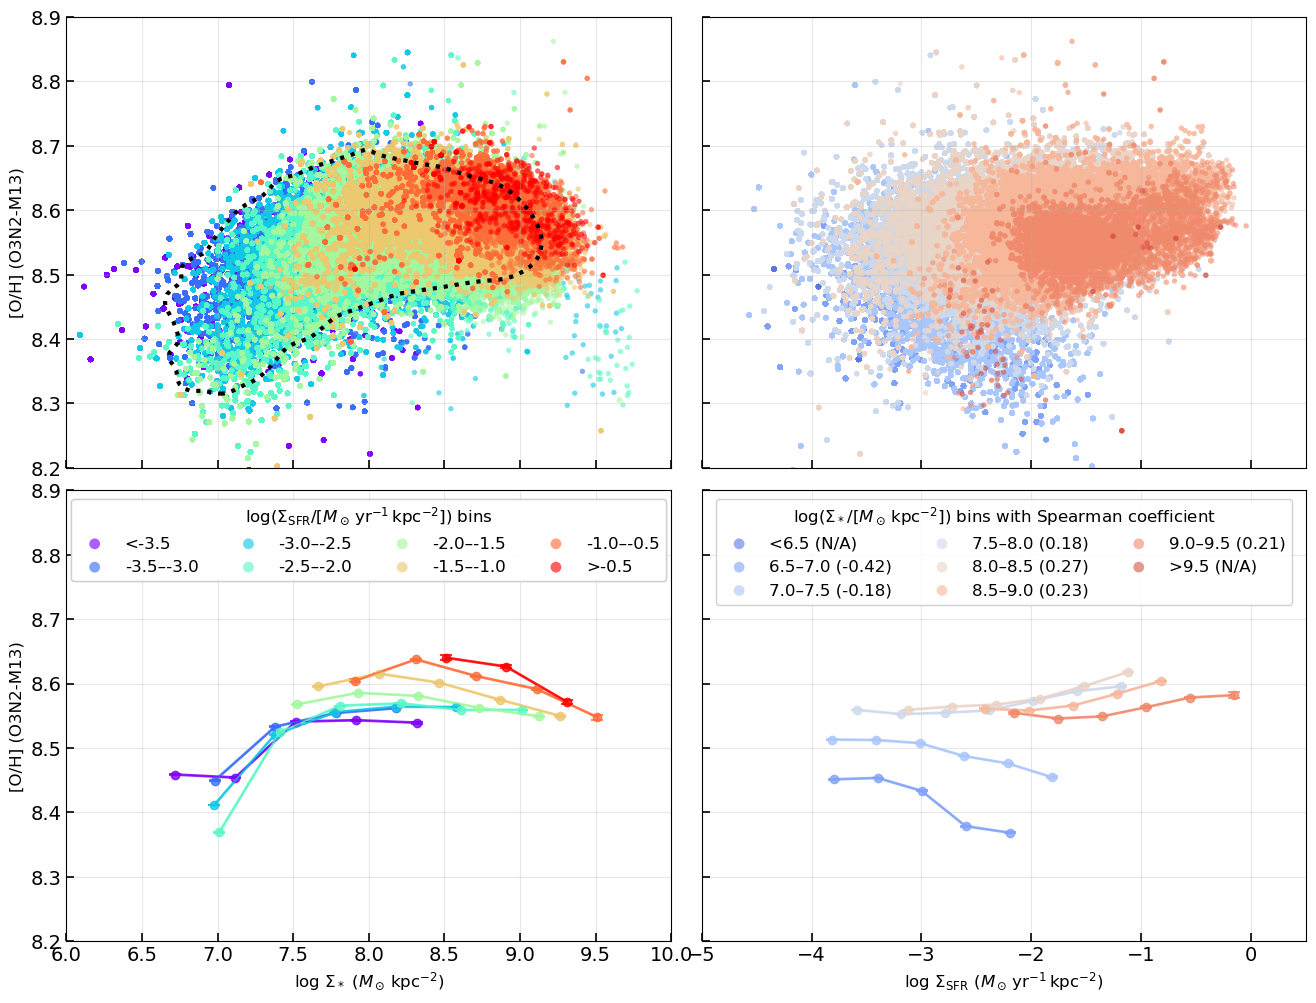


COMPLETED: Combined rMZR and Z_gas-Σ_SFR analysis (O3N2-M13 only)
Successfully created 2x2 subplot figure showing HII regions from 13 galaxies
Galaxies included: IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698
Excluded: NGC4383

Panel summary:
  Top-left: rMZR scatter (8 Σ_SFR bins)
  Top-right: Z_gas-Σ_SFR scatter (8 Σ_* bins)
  Bottom-left: rMZR median trends (8 Σ_SFR bins)
  Bottom-right: Z_gas-Σ_SFR median trends (8 Σ_* bins)
  Shared y-range: 8.2 to 8.9


In [4]:
# ------------------------------------------------------------------
# Combined Analysis: rMZR and Z_gas-Σ_SFR relation - HII regions only
# Using O3N2-M13 indicator only
# 2x2 subplot layout:
#   Top-left: rMZR scatter
#   Top-right: Z_gas-Σ_SFR scatter
#   Bottom-left: rMZR median trends
#   Bottom-right: Z_gas-Σ_SFR median trends
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits
import scipy.stats as stats
import scipy.ndimage as ndimage
from scipy.optimize import curve_fit

def load_maps_o3n2_m13(gal):
    """Load O3N2-M13 metallicity calibration for HII regions"""
    with fits.open(f'{gal}_SPATIAL_BINNING_maps_extended.fits') as h:
        sigM = h['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(f'{gal}_gas_BIN_maps_extended.fits') as h:
        sigSFR_HII = h['LOGSFR_SURFACE_DENSITY_HII'].data
        oh_o3n2_m13_HII = h['O_H_O3N2_M13_HII'].data
    return (sigM, sigSFR_HII, oh_o3n2_m13_HII)

def calculate_binned_stats(x_data, y_data, bin_width=0.4, min_pixels=20):
    """Calculate median and std in bins - only keep bins with >= min_pixels unique datapoints"""
    x_min, x_max = np.nanmin(x_data), np.nanmax(x_data)
    bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    medians, stds, counts, valid_centers, valid_bin_indices = [], [], [], [], []
    for i, (bin_start, bin_end) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
        in_bin = (x_data >= bin_start) & (x_data < bin_end)
        y_in_bin = y_data[in_bin]
        if len(np.unique(y_in_bin)) >= min_pixels:
            medians.append(np.median(y_in_bin))
            stds.append(np.std(y_in_bin))
            counts.append(len(y_in_bin))
            valid_centers.append(bin_centers[i])
            valid_bin_indices.append(i)
    return (np.array(valid_centers), np.array(medians), np.array(stds), np.array(counts), np.array(valid_bin_indices))

def mzr_model(x, a, b, c):
    return a + b * (x - c) * np.exp(-(x - c))

def compute_density_mask(x_vals, y_vals, x_range, y_range, nbins=100, sigma=2.0, return_contour=False):
    """Return mask for points inside the 95% density contour within given ranges."""
    mask_finite = np.isfinite(x_vals) & np.isfinite(y_vals)
    if not np.any(mask_finite):
        empty_mask = np.zeros_like(x_vals, dtype=bool)
        return (empty_mask, None, None) if return_contour else empty_mask
    x = x_vals[mask_finite]
    y = y_vals[mask_finite]
    H, xedges, yedges = np.histogram2d(x, y, bins=nbins, range=[x_range, y_range])
    H_smooth = ndimage.gaussian_filter(H, sigma=sigma)
    H_flat = np.sort(H_smooth.ravel())[::-1]
    H_cumsum = np.cumsum(H_flat)
    level_idx = np.searchsorted(H_cumsum, 0.95 * H_cumsum[-1])
    level_95 = H_flat[level_idx]
    x_centers = (xedges[:-1] + xedges[1:]) / 2
    y_centers = (yedges[:-1] + yedges[1:]) / 2
    X, Y = np.meshgrid(x_centers, y_centers)
    dx = (x_range[1] - x_range[0]) / nbins
    dy = (y_range[1] - y_range[0]) / nbins
    x_idx = (x - x_range[0]) / dx - 0.5
    y_idx = (y - y_range[0]) / dy - 0.5
    densities = ndimage.map_coordinates(H_smooth, [x_idx, y_idx], order=1, mode='constant', cval=0.0)
    mask_local = densities >= level_95
    full_mask = np.zeros_like(x_vals, dtype=bool)
    full_mask[np.where(mask_finite)[0]] = mask_local
    if return_contour:
        return full_mask, level_95, (X, Y, H_smooth)
    return full_mask

def plot_literature_mzr_fits(ax, show_legend=True):
    plot_data = []
    x_sanchez = np.linspace(7.05, 9.15, 200)
    a5, b5, c5 = 8.74, 0.013, 9.50
    y_sanchez13 = a5 + b5 * (x_sanchez - c5) * np.exp(-(x_sanchez - c5))
    plot_data.append((x_sanchez, y_sanchez13, 'Sánchez+13', ':', 'olive'))
    x_bb = np.linspace(7., 8.9, 200)
    a2, b2, c2 = 8.55, 0.014, 9.14
    y_bb16 = a2 + b2 * (x_bb - c2) * np.exp(-(x_bb - c2))
    plot_data.append((x_bb, y_bb16, 'Barrera-Ballesteros+16', '--', 'brown'))
    x_ef = np.linspace(6.5, 10.0, 200)
    a4, b4, c4 = 8.61, 0.008, 10.0
    y_ef17 = a4 + b4 * (x_ef - c4) * np.exp(-(x_ef - c4))
    plot_data.append((x_ef, y_ef17, 'Erroz-Ferrer+17', '-.', 'pink'))
    for x, y, label, linestyle, color in plot_data:
        ax.plot(x, y, label=label if show_legend else None, linewidth=2, linestyle=linestyle, color=color)

bins = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies = [f.name.split('_')[0] for f in bins]
excluded_galaxies = {'NGC4383'}
included_galaxies = []
all_logSigmaM_HII = []
all_logSigmaSFR_HII = []
all_oh_o3n2_m13_HII = []

print("="*80)
print("STEP 1: Collecting data from all galaxies for HII regions (O3N2-M13 only)...")
print("="*80)

for gal in galaxies:
    if gal in excluded_galaxies:
        print(f"  {gal}: excluded from analysis")
        continue
    bin_file = Path(f'{gal}_SPATIAL_BINNING_maps_extended.fits')
    gas_file = Path(f'{gal}_gas_BIN_maps_extended.fits')
    if bin_file.exists() and gas_file.exists():
        included_galaxies.append(gal)
        (logSigmaM, logSigmaSFR_HII, oh_o3n2_m13_HII) = load_maps_o3n2_m13(gal)
        common_mask_HII = (np.isfinite(logSigmaM) & np.isfinite(logSigmaSFR_HII) & np.isfinite(oh_o3n2_m13_HII))
        print(f"  {gal}: HII={np.sum(common_mask_HII)} pixels")
        all_logSigmaM_HII.extend(logSigmaM[common_mask_HII].flatten())
        all_logSigmaSFR_HII.extend(logSigmaSFR_HII[common_mask_HII].flatten())
        all_oh_o3n2_m13_HII.extend(oh_o3n2_m13_HII[common_mask_HII].flatten())
    else:
        print(f"  {gal}: Data files not found")

all_logSigmaM_HII = np.array(all_logSigmaM_HII)
all_logSigmaSFR_HII = np.array(all_logSigmaSFR_HII)
all_oh_o3n2_m13_HII = np.array(all_oh_o3n2_m13_HII)
print(f"\nTotal combined pixels (HII): {len(all_logSigmaM_HII)}")

print("\n" + "="*80)
print("STEP 2: Defining 8 SFR bins for rMZR")
print("="*80)
n_bins = 8
sfr_bin_edges = [-np.inf, -3.5, -3.0, -2.5, -2.0, -1.5, -1.0, -0.5, np.inf]
bin_labels = ['<-3.5', '-3.5–-3.0', '-3.0–-2.5', '-2.5–-2.0', '-2.0–-1.5', '-1.5–-1.0', '-1.0–-0.5', '>-0.5']
for i, label in enumerate(bin_labels):
    print(f"  Bin {i+1}: {label}")
colors_sfr = plt.cm.rainbow(np.linspace(0, 1, n_bins))

print("\n" + "="*80)
print("STEP 3: Defining 8 Σ_* bins for Z_gas-Σ_SFR")
print("="*80)
n_bins_sigmaM = 8
sigmaM_bin_edges = [-np.inf, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, np.inf]
bin_labels_sigmaM = ['<6.5', '6.5–7.0', '7.0–7.5', '7.5–8.0', '8.0–8.5', '8.5–9.0', '9.0–9.5', '>9.5']
for i, label in enumerate(bin_labels_sigmaM):
    print(f"  Bin {i+1}: {label}")
colors_sigmaM = plt.cm.coolwarm(np.linspace(0.1, 0.9, n_bins_sigmaM))

print("\n" + "="*80)
print("STEP 4: Creating combined 2x2 plot (O3N2-M13 only)")
print("="*80)
common_ylim = (8.2, 8.9)
x_range_rMZR = (6, 10)
x_range_Zgas = (-5.0, 0.5)
print(f"\nUsing uniform y-axis range: {common_ylim[0]:.1f} to {common_ylim[1]:.1f}")

fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharex='col', sharey='all')
plt.subplots_adjust(wspace=0.05, hspace=0.05)
oh_data_HII = all_oh_o3n2_m13_HII
calib_name_HII = 'O3N2-M13'
print(f"\nProcessing {calib_name_HII} calibration for HII regions:")
print(f"  HII {calib_name_HII} range: {np.min(oh_data_HII):.3f} to {np.max(oh_data_HII):.3f}")
ax_rMZR_scatter = axes[0, 0]
ax_Zgas_scatter = axes[0, 1]
ax_rMZR_median = axes[1, 0]
ax_Zgas_median = axes[1, 1]

mask_95_all_rMZR, level_95_all_rMZR, contour_data_rMZR = compute_density_mask(all_logSigmaM_HII, oh_data_HII, x_range_rMZR, common_ylim, return_contour=True)
max_typical_yerr_rMZR = np.nan
max_typical_yerr_Zgas = np.nan

print(f"\n--- Processing rMZR (8 Σ_SFR bins) ---")
legend_handles_sfr, legend_labels_sfr = [], []
valid_bins_rMZR = 0
for i in range(n_bins):
    in_bin_HII = (all_logSigmaSFR_HII >= sfr_bin_edges[i]) & (all_logSigmaSFR_HII < sfr_bin_edges[i + 1])
    n_pixels_HII = np.sum(in_bin_HII)
    if n_pixels_HII >= 10:
        x_bin_all = all_logSigmaM_HII[in_bin_HII]
        y_bin_all = oh_data_HII[in_bin_HII]
        scatter_hii = ax_rMZR_scatter.scatter(x_bin_all, y_bin_all, c=[colors_sfr[i]], s=15, alpha=0.6, edgecolors='none', rasterized=True)
        legend_handles_sfr.append(scatter_hii)
        legend_labels_sfr.append(bin_labels[i])
        mask_95_bin = compute_density_mask(x_bin_all, y_bin_all, x_range_rMZR, common_ylim)
        x_bin = x_bin_all[mask_95_bin]
        y_bin = y_bin_all[mask_95_bin]
        if len(x_bin) >= 10:
            mass_centers_HII, medians_HII, stds_HII, counts_HII, valid_bin_indices_HII = calculate_binned_stats(x_bin, y_bin, bin_width=0.4, min_pixels=20)
            if len(mass_centers_HII) > 1:
                yerr_HII = stds_HII / np.sqrt(counts_HII)
                typical_yerr = np.nanmedian(yerr_HII)
                print(f"    rMZR bin {i+1} {bin_labels[i]}: typical yerr (median σ/√N) = {typical_yerr:.4f}")
                if np.isfinite(typical_yerr):
                    max_typical_yerr_rMZR = np.nanmax([max_typical_yerr_rMZR, typical_yerr])
                ax_rMZR_median.errorbar(mass_centers_HII, medians_HII, yerr=yerr_HII, color=colors_sfr[i], marker='o', markersize=6, linewidth=1, capsize=4, capthick=1.5, alpha=0.8)
                for j in range(len(valid_bin_indices_HII) - 1):
                    current_bin_idx = valid_bin_indices_HII[j]
                    next_bin_idx = valid_bin_indices_HII[j + 1]
                    if next_bin_idx - current_bin_idx == 1:
                        ax_rMZR_median.plot([mass_centers_HII[j], mass_centers_HII[j + 1]], [medians_HII[j], medians_HII[j + 1]], color=colors_sfr[i], linewidth=2, alpha=0.8)
                valid_bins_rMZR += 1

if contour_data_rMZR is not None and level_95_all_rMZR is not None:
    ax_rMZR_scatter.contour(contour_data_rMZR[0], contour_data_rMZR[1], contour_data_rMZR[2].T, levels=[level_95_all_rMZR], colors='k', linewidths=3, linestyles=':')
ax_rMZR_scatter.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
ax_rMZR_scatter.grid(True, alpha=0.3)
ax_rMZR_scatter.set_xlim(*x_range_rMZR)
ax_rMZR_scatter.set_ylim(common_ylim)
ax_rMZR_median.set_xlabel(r'$\log\,\Sigma_* \ (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
ax_rMZR_median.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
ax_rMZR_median.grid(True, alpha=0.3)
ax_rMZR_median.set_xlim(*x_range_rMZR)
ax_rMZR_median.set_ylim(common_ylim)
legend1 = ax_rMZR_median.legend(legend_handles_sfr, legend_labels_sfr, loc='upper center', ncol=4, fontsize=12, framealpha=0.9, title=r'$\log(\Sigma_\mathrm{SFR}/[M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2}])$ bins', title_fontsize=12)
legend1_handles = getattr(legend1, "legend_handles", None)
if legend1_handles is None:
    legend1_handles = getattr(legend1, "legendHandles", [])
for handle in legend1_handles:
    try:
        handle.set_sizes([60])
    except Exception:
        pass
ax_rMZR_median.add_artist(legend1)
# if np.isfinite(max_typical_yerr_rMZR):
#     ax_rMZR_median.errorbar(x_range_rMZR[0] + 0.2, common_ylim[0] + 0.05, yerr=max_typical_yerr_rMZR, color='k', marker='o', markersize=4, linewidth=1, capsize=4, capthick=1.5)
print(f"  rMZR valid bins: {valid_bins_rMZR}")

print(f"\n--- Processing Z_gas-Σ_SFR (8 Σ_* bins) ---")
legend_handles_sigmaM, legend_labels_sigmaM_display = [], []
valid_bins_Zgas = 0
for i in range(n_bins_sigmaM):
    in_bin_HII = (all_logSigmaM_HII >= sigmaM_bin_edges[i]) & (all_logSigmaM_HII < sigmaM_bin_edges[i + 1])
    n_pixels_HII = np.sum(in_bin_HII)
    if n_pixels_HII >= 10:
        x_bin_all = all_logSigmaSFR_HII[in_bin_HII]
        y_bin_all = oh_data_HII[in_bin_HII]
        scatter_hii = ax_Zgas_scatter.scatter(x_bin_all, y_bin_all, c=[colors_sigmaM[i]], s=15, alpha=0.6, edgecolors='none', rasterized=True)
        legend_handles_sigmaM.append(scatter_hii)
        mask_95_bin = compute_density_mask(x_bin_all, y_bin_all, x_range_Zgas, common_ylim)
        x_bin = x_bin_all[mask_95_bin]
        y_bin = y_bin_all[mask_95_bin]
        spearman_text = "N/A"
        if len(x_bin) > 1:
            y_mean, y_std = np.nanmean(y_bin), np.nanstd(y_bin)
            x_mean, x_std = np.nanmean(x_bin), np.nanstd(x_bin)
            mask_clip = (np.abs(y_bin - y_mean) < 3 * y_std) & (np.abs(x_bin - x_mean) < 3 * x_std)
            x_clipped = x_bin[mask_clip]
            y_clipped = y_bin[mask_clip]
            sfr_centers_HII, medians_HII, stds_HII, counts_HII, valid_bin_indices_HII = calculate_binned_stats(x_clipped, y_clipped, bin_width=0.4, min_pixels=20)
            if len(sfr_centers_HII) > 1:
                if len(x_clipped) > 10:
                    corr, _ = stats.spearmanr(x_clipped, y_clipped)
                    spearman_text = f"{corr:.2f}"
                yerr_HII = stds_HII / np.sqrt(counts_HII)
                typical_yerr = np.nanmedian(yerr_HII)
                print(f"    Zgas-ΣSFR bin {i+1} {bin_labels_sigmaM[i]}: typical yerr (median σ/√N) = {typical_yerr:.4f}")
                if np.isfinite(typical_yerr):
                    max_typical_yerr_Zgas = np.nanmax([max_typical_yerr_Zgas, typical_yerr])
                ax_Zgas_median.errorbar(sfr_centers_HII, medians_HII, yerr=yerr_HII, color=colors_sigmaM[i], marker='o', markersize=6, linewidth=1, capsize=4, capthick=1.5, alpha=0.8)
                for j in range(len(valid_bin_indices_HII) - 1):
                    current_bin_idx = valid_bin_indices_HII[j]
                    next_bin_idx = valid_bin_indices_HII[j + 1]
                    if next_bin_idx - current_bin_idx == 1:
                        ax_Zgas_median.plot([sfr_centers_HII[j], sfr_centers_HII[j + 1]], [medians_HII[j], medians_HII[j + 1]], color=colors_sigmaM[i], linewidth=2, alpha=0.8)
                valid_bins_Zgas += 1
        legend_labels_sigmaM_display.append(f"{bin_labels_sigmaM[i]} ({spearman_text})")

ax_Zgas_scatter.grid(True, alpha=0.3)
ax_Zgas_scatter.set_xlim(*x_range_Zgas)
ax_Zgas_scatter.set_ylim(common_ylim)
ax_Zgas_median.set_xlabel(r'$\log\,\Sigma_\mathrm{SFR} \ (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', fontsize=12)
ax_Zgas_median.grid(True, alpha=0.3)
ax_Zgas_median.set_xlim(*x_range_Zgas)
ax_Zgas_median.set_ylim(common_ylim)
legend2 = ax_Zgas_median.legend(legend_handles_sigmaM, legend_labels_sigmaM_display, loc='upper center', ncol=3, fontsize=12, framealpha=0.9, title=r'$\log(\Sigma_*/[M_\odot\,\mathrm{kpc}^{-2}])$ bins with Spearman coefficient', title_fontsize=12)
legend2_handles = getattr(legend2, "legend_handles", None)
if legend2_handles is None:
    legend2_handles = getattr(legend2, "legendHandles", [])
for handle in legend2_handles:
    try:
        handle.set_sizes([60])
    except Exception:
        pass
# if np.isfinite(max_typical_yerr_Zgas):
#     ax_Zgas_median.errorbar(x_range_Zgas[0] + 0.2, common_ylim[0] + 0.05, yerr=max_typical_yerr_Zgas, color='k', marker='o', markersize=4, linewidth=1, capsize=4, capthick=1.5)
print(f"  Z_gas-Σ_SFR valid bins: {valid_bins_Zgas}")

# plt.savefig('Plot_Paper_1/MAUVE_MUSE_rMZR_Zgas_SigmaSFR_O3N2M13.png', dpi=600, bbox_inches='tight')
# plt.savefig('Plot_Paper_1/MAUVE_MUSE_rMZR_Zgas_SigmaSFR_O3N2M13.pdf', bbox_inches='tight')
plt.show()

print("\n" + "="*80)
print("COMPLETED: Combined rMZR and Z_gas-Σ_SFR analysis (O3N2-M13 only)")
print("="*80)
print(f"Successfully created 2x2 subplot figure showing HII regions from {len(included_galaxies)} galaxies")
print(f"Galaxies included: {', '.join(included_galaxies)}")
print(f"Excluded: {', '.join(sorted(excluded_galaxies))}")
print("\nPanel summary:")
print("  Top-left: rMZR scatter (8 Σ_SFR bins)")
print("  Top-right: Z_gas-Σ_SFR scatter (8 Σ_* bins)")
print("  Bottom-left: rMZR median trends (8 Σ_SFR bins)")
print("  Bottom-right: Z_gas-Σ_SFR median trends (8 Σ_* bins)")
print(f"  Shared y-range: {common_ylim[0]:.1f} to {common_ylim[1]:.1f}")

STEP 1: Collecting data from all galaxies for HII regions (O3N2-M13 only)...
  IC3392: HII=14906 pixels
  NGC4064: HII=7077 pixels
  NGC4192: HII=146165 pixels
  NGC4293: HII=5715 pixels
  NGC4298: HII=156571 pixels
  NGC4330: HII=43026 pixels
  NGC4383: excluded from analysis
  NGC4396: HII=81745 pixels
  NGC4419: HII=7386 pixels
  NGC4457: HII=6355 pixels
  NGC4501: HII=261541 pixels
  NGC4522: HII=39619 pixels
  NGC4694: HII=2586 pixels
  NGC4698: HII=10181 pixels

Total combined pixels (HII): 782873

STEP 2: Defining 8 sSFR bins for rMZR
  Bin 1: -12.53–-10.80
  Bin 2: -10.80–-10.63
  Bin 3: -10.63–-10.49
  Bin 4: -10.49–-10.35
  Bin 5: -10.35–-10.20
  Bin 6: -10.20–-10.03
  Bin 7: -10.03–-9.79
  Bin 8: -9.79–-8.24

STEP 3: Defining 8 Σ_* bins for Z_gas-sSFR
  Bin 1: <6.5
  Bin 2: 6.5–7.0
  Bin 3: 7.0–7.5
  Bin 4: 7.5–8.0
  Bin 5: 8.0–8.5
  Bin 6: 8.5–9.0
  Bin 7: 9.0–9.5
  Bin 8: >9.5

STEP 4: Creating combined 2x2 plot (O3N2-M13 only)

--- Processing rMZR (8 sSFR bins) ---
  rMZR

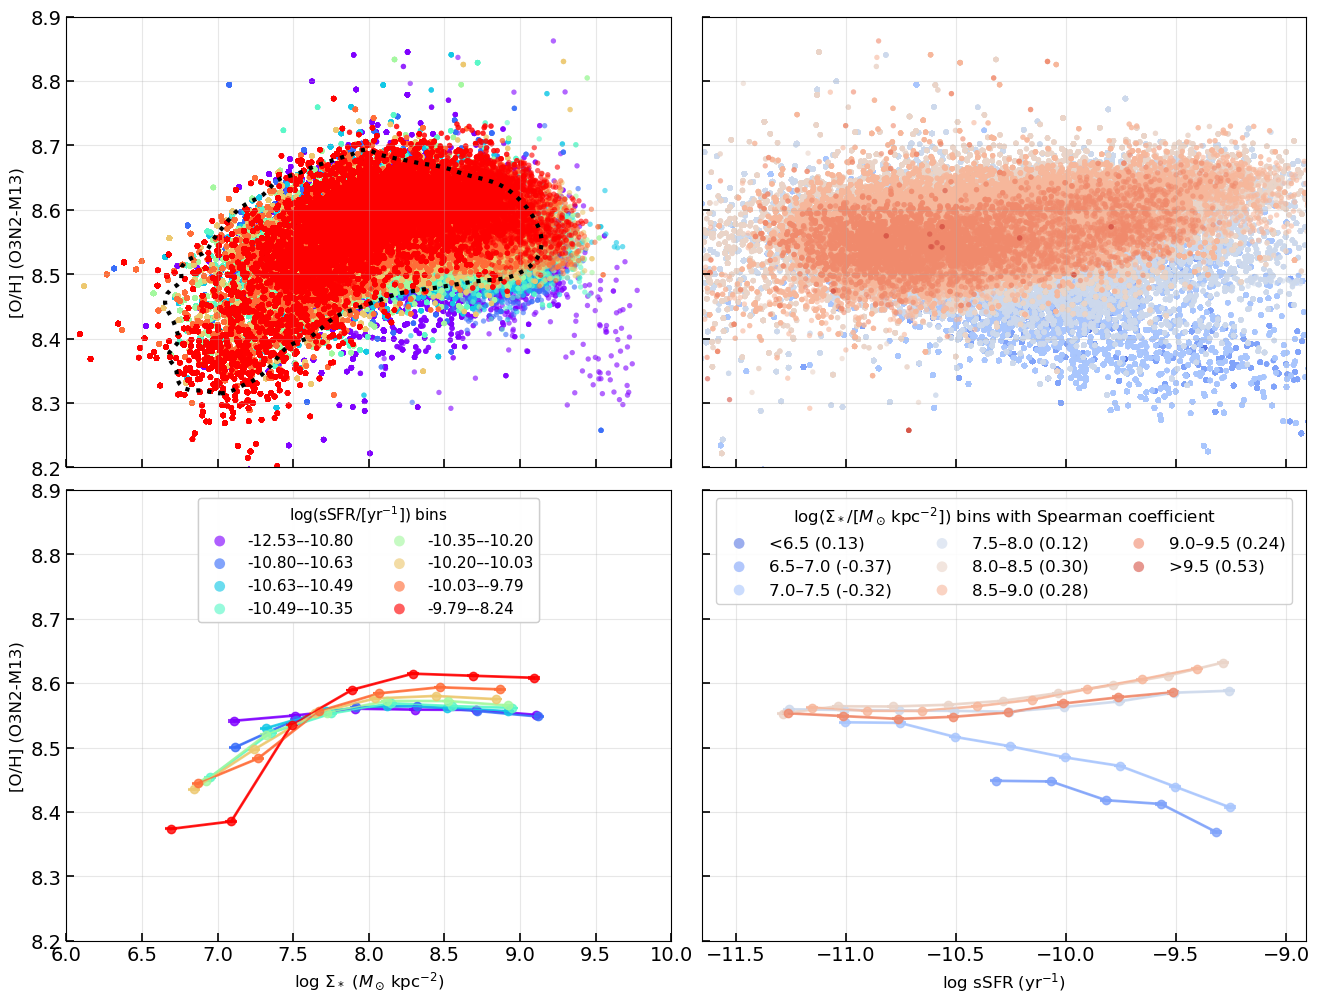


COMPLETED: Combined rMZR and Z_gas-sSFR analysis (O3N2-M13 only)
Successfully created 2x2 subplot figure showing HII regions from 13 galaxies
Galaxies included: IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698
Excluded: NGC4383

Panel summary:
  Top-left: rMZR scatter (8 sSFR bins)
  Top-right: Z_gas-sSFR scatter (8 Σ_* bins)
  Bottom-left: rMZR median trends (8 sSFR bins)
  Bottom-right: Z_gas-sSFR median trends (8 Σ_* bins)
  Shared y-range: 8.2 to 8.9


In [5]:
# ------------------------------------------------------------------
# Combined Analysis: rMZR and Z_gas-sSFR relation - HII regions only
# Using O3N2-M13 indicator only
# 2x2 subplot layout:
#   Top-left: rMZR scatter (color-coded by sSFR bins)
#   Top-right: Z_gas-sSFR scatter (color-coded by Σ_* bins)
#   Bottom-left: rMZR median trends (sSFR bins)
#   Bottom-right: Z_gas-sSFR median trends (Σ_* bins)
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits
import scipy.stats as stats
import scipy.ndimage as ndimage


def load_maps_o3n2_m13(gal):
    with fits.open(f'{gal}_SPATIAL_BINNING_maps_extended.fits') as h:
        sigM = h['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(f'{gal}_gas_BIN_maps_extended.fits') as h:
        sigSFR_HII = h['LOGSFR_SURFACE_DENSITY_HII'].data
        oh_o3n2_m13_HII = h['O_H_O3N2_M13_HII'].data
    return sigM, sigSFR_HII, oh_o3n2_m13_HII


def calculate_binned_stats(x_data, y_data, bin_width=0.4, min_pixels=20):
    x_min, x_max = np.nanmin(x_data), np.nanmax(x_data)
    bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    medians, stds, counts, valid_centers, valid_bin_indices = [], [], [], [], []
    for i, (bin_start, bin_end) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
        in_bin = (x_data >= bin_start) & (x_data < bin_end)
        y_in_bin = y_data[in_bin]
        if len(np.unique(y_in_bin)) >= min_pixels:
            medians.append(np.median(y_in_bin))
            stds.append(np.std(y_in_bin))
            counts.append(len(y_in_bin))
            valid_centers.append(bin_centers[i])
            valid_bin_indices.append(i)
    return np.array(valid_centers), np.array(medians), np.array(stds), np.array(counts), np.array(valid_bin_indices)


def compute_density_mask(x_vals, y_vals, x_range, y_range, nbins=100, sigma=2.0, return_contour=False):
    mask_finite = np.isfinite(x_vals) & np.isfinite(y_vals)
    if not np.any(mask_finite):
        empty_mask = np.zeros_like(x_vals, dtype=bool)
        return (empty_mask, None, None) if return_contour else empty_mask

    x = x_vals[mask_finite]
    y = y_vals[mask_finite]
    H, xedges, yedges = np.histogram2d(x, y, bins=nbins, range=[x_range, y_range])
    H_smooth = ndimage.gaussian_filter(H, sigma=sigma)

    H_flat = np.sort(H_smooth.ravel())[::-1]
    H_cumsum = np.cumsum(H_flat)
    level_idx = np.searchsorted(H_cumsum, 0.95 * H_cumsum[-1])
    level_95 = H_flat[level_idx]

    dx = (x_range[1] - x_range[0]) / nbins
    dy = (y_range[1] - y_range[0]) / nbins
    x_idx = (x - x_range[0]) / dx - 0.5
    y_idx = (y - y_range[0]) / dy - 0.5
    densities = ndimage.map_coordinates(H_smooth, [x_idx, y_idx], order=1, mode='constant', cval=0.0)

    mask_local = densities >= level_95
    full_mask = np.zeros_like(x_vals, dtype=bool)
    full_mask[np.where(mask_finite)[0]] = mask_local

    if return_contour:
        x_centers = (xedges[:-1] + xedges[1:]) / 2
        y_centers = (yedges[:-1] + yedges[1:]) / 2
        X, Y = np.meshgrid(x_centers, y_centers)
        return full_mask, level_95, (X, Y, H_smooth)
    return full_mask


bins = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies = [f.name.split('_')[0] for f in bins]
excluded_galaxies = {'NGC4383'}
included_galaxies = []

all_logSigmaM_HII = []
all_logSigmaSFR_HII = []
all_logssfr_HII = []
all_oh_o3n2_m13_HII = []

print('=' * 80)
print('STEP 1: Collecting data from all galaxies for HII regions (O3N2-M13 only)...')
print('=' * 80)

for gal in galaxies:
    if gal in excluded_galaxies:
        print(f'  {gal}: excluded from analysis')
        continue

    bin_file = Path(f'{gal}_SPATIAL_BINNING_maps_extended.fits')
    gas_file = Path(f'{gal}_gas_BIN_maps_extended.fits')
    if not (bin_file.exists() and gas_file.exists()):
        print(f'  {gal}: Data files not found')
        continue

    included_galaxies.append(gal)
    logSigmaM, logSigmaSFR_HII, oh_o3n2_m13_HII = load_maps_o3n2_m13(gal)
    common_mask_HII = np.isfinite(logSigmaM) & np.isfinite(logSigmaSFR_HII) & np.isfinite(oh_o3n2_m13_HII)

    logssfr_HII = logSigmaSFR_HII - logSigmaM

    print(f'  {gal}: HII={np.sum(common_mask_HII)} pixels')
    all_logSigmaM_HII.extend(logSigmaM[common_mask_HII].ravel())
    all_logSigmaSFR_HII.extend(logSigmaSFR_HII[common_mask_HII].ravel())
    all_logssfr_HII.extend(logssfr_HII[common_mask_HII].ravel())
    all_oh_o3n2_m13_HII.extend(oh_o3n2_m13_HII[common_mask_HII].ravel())

all_logSigmaM_HII = np.array(all_logSigmaM_HII)
all_logSigmaSFR_HII = np.array(all_logSigmaSFR_HII)
all_logssfr_HII = np.array(all_logssfr_HII)
all_oh_o3n2_m13_HII = np.array(all_oh_o3n2_m13_HII)

print(f'\nTotal combined pixels (HII): {len(all_logSigmaM_HII)}')

print('\n' + '=' * 80)
print('STEP 2: Defining 8 sSFR bins for rMZR')
print('=' * 80)
n_bins = 8
ssfr_bin_edges = np.percentile(all_logssfr_HII, np.linspace(0, 100, n_bins + 1))
ssfr_bin_edges[0] -= 1e-6
ssfr_bin_edges[-1] += 1e-6
bin_labels_ssfr = [f'{ssfr_bin_edges[i]:.2f}–{ssfr_bin_edges[i + 1]:.2f}' for i in range(n_bins)]
for i, label in enumerate(bin_labels_ssfr):
    print(f'  Bin {i + 1}: {label}')
colors_ssfr = plt.cm.rainbow(np.linspace(0, 1, n_bins))

print('\n' + '=' * 80)
print('STEP 3: Defining 8 Σ_* bins for Z_gas-sSFR')
print('=' * 80)
n_bins_sigmaM = 8
sigmaM_bin_edges = [-np.inf, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, np.inf]
bin_labels_sigmaM = ['<6.5', '6.5–7.0', '7.0–7.5', '7.5–8.0', '8.0–8.5', '8.5–9.0', '9.0–9.5', '>9.5']
for i, label in enumerate(bin_labels_sigmaM):
    print(f'  Bin {i + 1}: {label}')
colors_sigmaM = plt.cm.coolwarm(np.linspace(0.1, 0.9, n_bins_sigmaM))

print('\n' + '=' * 80)
print('STEP 4: Creating combined 2x2 plot (O3N2-M13 only)')
print('=' * 80)
common_ylim = (8.2, 8.9)
x_range_rMZR = (6, 10)
x_min_ssfr = np.nanpercentile(all_logssfr_HII, 1)
x_max_ssfr = np.nanpercentile(all_logssfr_HII, 99)
x_range_Zgas = (x_min_ssfr - 0.2, x_max_ssfr + 0.2)

fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharex='col', sharey='all')
plt.subplots_adjust(wspace=0.05, hspace=0.05)
ax_rMZR_scatter, ax_Zgas_scatter = axes[0, 0], axes[0, 1]
ax_rMZR_median, ax_Zgas_median = axes[1, 0], axes[1, 1]

oh_data_HII = all_oh_o3n2_m13_HII
calib_name_HII = 'O3N2-M13'

mask_95_all_rMZR, level_95_all_rMZR, contour_data_rMZR = compute_density_mask(
    all_logSigmaM_HII, oh_data_HII, x_range_rMZR, common_ylim, return_contour=True
)

print('\n--- Processing rMZR (8 sSFR bins) ---')
legend_handles_ssfr, legend_labels_ssfr = [], []
valid_bins_rMZR = 0
for i in range(n_bins):
    in_bin_HII = (all_logssfr_HII >= ssfr_bin_edges[i]) & (all_logssfr_HII < ssfr_bin_edges[i + 1])
    if np.sum(in_bin_HII) < 10:
        continue

    x_bin_all = all_logSigmaM_HII[in_bin_HII]
    y_bin_all = oh_data_HII[in_bin_HII]

    scatter_hii = ax_rMZR_scatter.scatter(x_bin_all, y_bin_all, c=[colors_ssfr[i]], s=15, alpha=0.6, edgecolors='none', rasterized=True)
    legend_handles_ssfr.append(scatter_hii)
    legend_labels_ssfr.append(bin_labels_ssfr[i])

    mask_95_bin = compute_density_mask(x_bin_all, y_bin_all, x_range_rMZR, common_ylim)
    x_bin, y_bin = x_bin_all[mask_95_bin], y_bin_all[mask_95_bin]
    if len(x_bin) < 10:
        continue

    mass_centers_HII, medians_HII, stds_HII, counts_HII, valid_bin_indices_HII = calculate_binned_stats(
        x_bin, y_bin, bin_width=0.4, min_pixels=20
    )
    if len(mass_centers_HII) <= 1:
        continue

    yerr_HII = stds_HII / np.sqrt(counts_HII)
    ax_rMZR_median.errorbar(
        mass_centers_HII, medians_HII, yerr=yerr_HII,
        color=colors_ssfr[i], marker='o', markersize=6, linewidth=1, capsize=4, capthick=1.5, alpha=0.8
    )
    for j in range(len(valid_bin_indices_HII) - 1):
        if valid_bin_indices_HII[j + 1] - valid_bin_indices_HII[j] == 1:
            ax_rMZR_median.plot(
                [mass_centers_HII[j], mass_centers_HII[j + 1]],
                [medians_HII[j], medians_HII[j + 1]],
                color=colors_ssfr[i], linewidth=2, alpha=0.8
            )
    valid_bins_rMZR += 1

if contour_data_rMZR is not None and level_95_all_rMZR is not None:
    ax_rMZR_scatter.contour(
        contour_data_rMZR[0], contour_data_rMZR[1], contour_data_rMZR[2].T,
        levels=[level_95_all_rMZR], colors='k', linewidths=3, linestyles=':'
    )

ax_rMZR_scatter.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
ax_rMZR_scatter.grid(True, alpha=0.3)
ax_rMZR_scatter.set_xlim(*x_range_rMZR)
ax_rMZR_scatter.set_ylim(common_ylim)

ax_rMZR_median.set_xlabel(r'$\log\,\Sigma_* \ (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
ax_rMZR_median.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
ax_rMZR_median.grid(True, alpha=0.3)
ax_rMZR_median.set_xlim(*x_range_rMZR)
ax_rMZR_median.set_ylim(common_ylim)

legend1 = ax_rMZR_median.legend(
    legend_handles_ssfr, legend_labels_ssfr,
    loc='upper center', ncol=2, fontsize=11, framealpha=0.9,
    title=r'$\log(\mathrm{sSFR}/[\mathrm{yr}^{-1}])$ bins', title_fontsize=11
)
legend1_handles = getattr(legend1, 'legend_handles', None)
if legend1_handles is None:
    legend1_handles = getattr(legend1, 'legendHandles', [])
for handle in legend1_handles:
    try:
        handle.set_sizes([60])
    except Exception:
        pass
ax_rMZR_median.add_artist(legend1)
print(f'  rMZR valid bins: {valid_bins_rMZR}')

print('\n--- Processing Z_gas-sSFR (8 Σ_* bins) ---')
legend_handles_sigmaM, legend_labels_sigmaM_display = [], []
valid_bins_Zgas = 0
for i in range(n_bins_sigmaM):
    in_bin_HII = (all_logSigmaM_HII >= sigmaM_bin_edges[i]) & (all_logSigmaM_HII < sigmaM_bin_edges[i + 1])
    if np.sum(in_bin_HII) < 10:
        legend_labels_sigmaM_display.append(f'{bin_labels_sigmaM[i]} (N/A)')
        continue

    x_bin_all = all_logssfr_HII[in_bin_HII]
    y_bin_all = oh_data_HII[in_bin_HII]

    scatter_hii = ax_Zgas_scatter.scatter(x_bin_all, y_bin_all, c=[colors_sigmaM[i]], s=15, alpha=0.6, edgecolors='none', rasterized=True)
    legend_handles_sigmaM.append(scatter_hii)

    mask_95_bin = compute_density_mask(x_bin_all, y_bin_all, x_range_Zgas, common_ylim)
    x_bin, y_bin = x_bin_all[mask_95_bin], y_bin_all[mask_95_bin]

    spearman_text = 'N/A'
    if len(x_bin) > 10:
        corr, _ = stats.spearmanr(x_bin, y_bin)
        spearman_text = f'{corr:.2f}'

    if len(x_bin) > 1:
        ssfr_centers_HII, medians_HII, stds_HII, counts_HII, valid_bin_indices_HII = calculate_binned_stats(
            x_bin, y_bin, bin_width=0.25, min_pixels=20
        )
        if len(ssfr_centers_HII) > 1:
            yerr_HII = stds_HII / np.sqrt(counts_HII)
            ax_Zgas_median.errorbar(
                ssfr_centers_HII, medians_HII, yerr=yerr_HII,
                color=colors_sigmaM[i], marker='o', markersize=6, linewidth=1, capsize=4, capthick=1.5, alpha=0.8
            )
            for j in range(len(valid_bin_indices_HII) - 1):
                if valid_bin_indices_HII[j + 1] - valid_bin_indices_HII[j] == 1:
                    ax_Zgas_median.plot(
                        [ssfr_centers_HII[j], ssfr_centers_HII[j + 1]],
                        [medians_HII[j], medians_HII[j + 1]],
                        color=colors_sigmaM[i], linewidth=2, alpha=0.8
                    )
            valid_bins_Zgas += 1

    legend_labels_sigmaM_display.append(f'{bin_labels_sigmaM[i]} ({spearman_text})')

ax_Zgas_scatter.grid(True, alpha=0.3)
ax_Zgas_scatter.set_xlim(*x_range_Zgas)
ax_Zgas_scatter.set_ylim(common_ylim)

ax_Zgas_median.set_xlabel(r'$\log\,\mathrm{sSFR}\;(\mathrm{yr}^{-1})$', fontsize=12)
ax_Zgas_median.grid(True, alpha=0.3)
ax_Zgas_median.set_xlim(*x_range_Zgas)
ax_Zgas_median.set_ylim(common_ylim)

legend2 = ax_Zgas_median.legend(
    legend_handles_sigmaM, legend_labels_sigmaM_display[:len(legend_handles_sigmaM)],
    loc='upper center', ncol=3, fontsize=12, framealpha=0.9,
    title=r'$\log(\Sigma_*/[M_\odot\,\mathrm{kpc}^{-2}])$ bins with Spearman coefficient', title_fontsize=12
)
legend2_handles = getattr(legend2, 'legend_handles', None)
if legend2_handles is None:
    legend2_handles = getattr(legend2, 'legendHandles', [])
for handle in legend2_handles:
    try:
        handle.set_sizes([60])
    except Exception:
        pass

print(f'  Z_gas-sSFR valid bins: {valid_bins_Zgas}')

plt.show()

print('\n' + '=' * 80)
print('COMPLETED: Combined rMZR and Z_gas-sSFR analysis (O3N2-M13 only)')
print('=' * 80)
print(f'Successfully created 2x2 subplot figure showing HII regions from {len(included_galaxies)} galaxies')
print(f'Galaxies included: {", ".join(included_galaxies)}')
print(f'Excluded: {", ".join(sorted(excluded_galaxies))}')
print('\nPanel summary:')
print('  Top-left: rMZR scatter (8 sSFR bins)')
print('  Top-right: Z_gas-sSFR scatter (8 Σ_* bins)')
print('  Bottom-left: rMZR median trends (8 sSFR bins)')
print('  Bottom-right: Z_gas-sSFR median trends (8 Σ_* bins)')
print(f'  Shared y-range: {common_ylim[0]:.1f} to {common_ylim[1]:.1f}')

Offset relations and Spearman rho vs Σ_* (excluding: {'NGC4383'})
All galaxies (for color assignment): IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4383, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698
Galaxies used in this analysis: IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698

Processing IC3392 ...
  Σ* range (95%): 7.739 to 8.911
  Global Δlog(Σ_SFR) axis limits: ±1.175
  Global Δ[O/H] axis limits: ±0.262
  Spearman rho in each Σ_* bin (3σ clip + trend, per galaxy):
    Bin 01 (7.84): n=450, r=N/A (no trend or too few in 3σ)
    Bin 02 (8.03): n=2240, r=0.433 (p=5.28e-102)
    Bin 03 (8.23): n=5467, r=0.311 (p=3.25e-121)
    Bin 04 (8.42): n=3864, r=0.268 (p=5.05e-63)
    Bin 05 (8.62): n=1435, r=0.238 (p=9.89e-20)
    Bin 06 (8.81): n=705, r=0.097 (p=0.0101)

Processing NGC4064 ...
  Σ* range (95%): 7.180 to 9.130
  Global Δlog(Σ_SFR) axis limits: ±2.070
  Global Δ[O/H] axis limits: ±0.26

/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_12729/1746847697.py:453: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


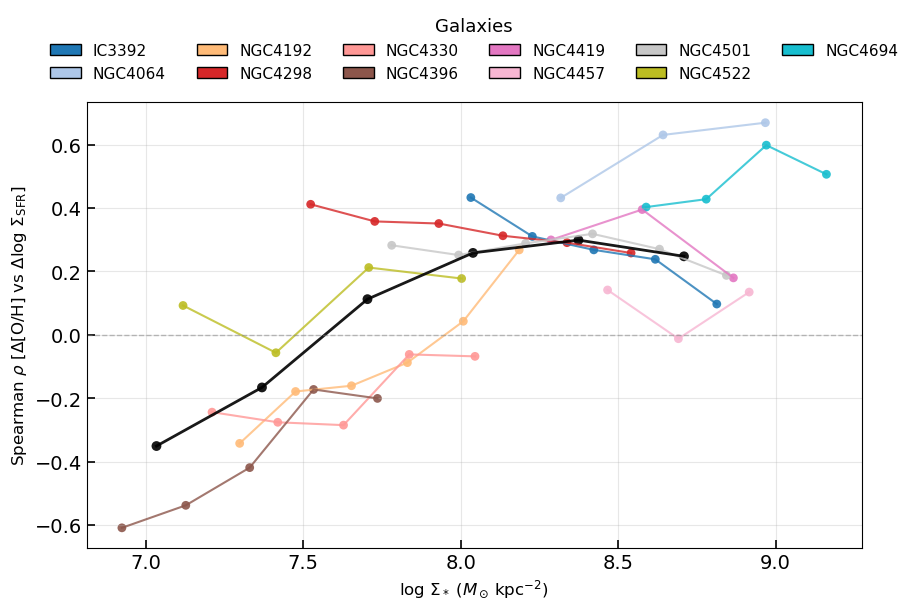

In [6]:
# ------------------------------------------------------------------
# Offset relations: Δ[O/H] vs Δlog Σ_SFR in Σ_* bins
# For all galaxies (excluding NGC4383) and Spearman rho vs Σ_* summary
# Spearman rho uses only points inside 95% contour and only if trend exists
# ------------------------------------------------------------------
from pathlib import Path
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
import matplotlib.gridspec as gridspec
from scipy.stats import spearmanr
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# ------------------------------------------------------------------
# Helper: read the required maps
# ------------------------------------------------------------------
def load_maps(gal):
    spatial_path = f'{gal}_SPATIAL_BINNING_maps_extended.fits'
    gas_path = f'{gal}_gas_BIN_maps_extended.fits'

    if not (Path(spatial_path).exists() and Path(gas_path).exists()):
        raise FileNotFoundError(f'Required FITS files for {gal} not found.')

    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(gas_path) as h_gas:
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
        if 'O_H_O3N2_M14_HII' in h_gas:
            oh_map = h_gas['O_H_O3N2_M14_HII'].data
            indicator_name = 'O3N2-M14'
        elif 'O_H_O3N2_M13_HII' in h_gas:
            print(f"Warning: O3N2-M14 not available for {gal}; using O3N2-M13 instead.")
            oh_map = h_gas['O_H_O3N2_M13_HII'].data
            indicator_name = 'O3N2-M13'
        else:
            available = [hdu.name for hdu in h_gas]
            raise KeyError(f"No O3N2 metallicity extension (M14/M13) found for {gal}. Available: {available}")
    return sigM, sigSFR, oh_map, indicator_name

# ------------------------------------------------------------------
# Helper: calculate binned statistics with unique-count requirement
# ------------------------------------------------------------------
def calculate_binned_stats(x_data, y_data, bin_width=0.2, min_unique=20):
    """Calculate median and std in x-bins, requiring >= min_unique unique y values."""
    x_data = np.asarray(x_data)
    y_data = np.asarray(y_data)

    finite = np.isfinite(x_data) & np.isfinite(y_data)
    if np.sum(finite) == 0:
        return np.array([]), np.array([]), np.array([]), np.array([])

    x_min, x_max = np.nanmin(x_data[finite]), np.nanmax(x_data[finite])
    if not np.isfinite(x_min) or not np.isfinite(x_max) or x_min == x_max:
        return np.array([]), np.array([]), np.array([]), np.array([])

    bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
    if bin_edges.size < 2:
        return np.array([]), np.array([]), np.array([]), np.array([])

    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    medians = []
    stds = []
    counts = []
    valid_centers = []

    for i, (bin_start, bin_end) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
        in_bin = finite & (x_data >= bin_start) & (x_data < bin_end)
        if np.sum(in_bin) == 0:
            continue

        y_in_bin = y_data[in_bin]
        if len(np.unique(y_in_bin)) >= min_unique:
            medians.append(np.nanmedian(y_in_bin))
            stds.append(np.nanstd(y_in_bin))
            counts.append(len(y_in_bin))
            valid_centers.append(bin_centers[i])

    return (np.array(valid_centers), np.array(medians),
            np.array(stds), np.array(counts))

# ------------------------------------------------------------------
# Galaxy list and color map (reserve color for excluded galaxy)
# ------------------------------------------------------------------
all_bin_centers = []  # Σ_* bin centers for which rho is valid (per-galaxy)
all_rho_values = []     # Spearman rho (per-galaxy)
all_galaxy_indices = []

# Also store all spaxels across galaxies to compute a global trend
global_sigM_list = []
global_sigSFR_list = []
global_oh_list = []
global_gal_index_list = []

# Build full galaxy list from available FITS files (including excluded)
bins = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies_all = [f.name.split('_')[0] for f in bins]
excluded_galaxies = {'NGC4383'}

# Build galaxy -> color mapping over ALL galaxies (so excluded keeps its color)
galaxy_colors_all = plt.cm.tab20(np.linspace(0, 1, len(galaxies_all)))
galaxy_color_dict = dict(zip(galaxies_all, galaxy_colors_all))

# Now define the working sample that EXCLUDES NGC4383 for analysis/plotting
galaxies = [g for g in galaxies_all if g not in excluded_galaxies]

print("=" * 80)
print(f"Offset relations and Spearman rho vs Σ_* (excluding: {excluded_galaxies})")
print("All galaxies (for color assignment):", ", ".join(galaxies_all))
print("Galaxies used in this analysis:", ", ".join(galaxies))
print("=" * 80)

# ------------------------------------------------------------------
# Loop over galaxies and compute Spearman rho per Σ_* bin (per-galaxy)
# and collect global spaxels for combined trend
# ------------------------------------------------------------------
for gal_index, gal in enumerate(galaxies):
    print(f"\nProcessing {gal} ...")
    try:
        sigM, sigSFR, oh_o3n2_map, indicator_name = load_maps(gal)
    except Exception as e:
        print(f"  Skipping {gal}: {e}")
        continue

    valid_sfr = np.isfinite(sigSFR)
    valid_oh = np.isfinite(oh_o3n2_map)
    valid_sigM = np.isfinite(sigM)
    valid_all = valid_sfr & valid_oh & valid_sigM

    if np.sum(valid_all) == 0:
        print("  No valid pixels.")
        continue

    # Collect into global arrays for combined analysis
    global_sigM_list.append(sigM[valid_all].ravel())
    global_sigSFR_list.append(sigSFR[valid_all].ravel())
    global_oh_list.append(oh_o3n2_map[valid_all].ravel())
    global_gal_index_list.append(np.full(np.sum(valid_all), gal_index, dtype=int))

    # 1. Define 6 Σ_* bins for this galaxy (spanning 95% population)
    n_bins = 6
    sigmaM_min = np.nanpercentile(sigM[valid_all], 2.5)
    sigmaM_max = np.nanpercentile(sigM[valid_all], 97.5)
    sigmaM_bin_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins + 1)
    sigmaM_bin_centers = 0.5 * (sigmaM_bin_edges[:-1] + sigmaM_bin_edges[1:])

    # 2. Global symmetric limits for this galaxy (for reference / consistency)
    global_max_abs_sfr = 0
    global_max_abs_oh = 0
    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
        else:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all

        if np.sum(bin_mask) > 0:
            sfr_bin = sigSFR[bin_mask]
            oh_bin = oh_o3n2_map[bin_mask]

            sfr_offset = sfr_bin - np.mean(sfr_bin)
            oh_offset = oh_bin - np.mean(oh_bin)

            if np.any(np.isfinite(sfr_offset)):
                global_max_abs_sfr = max(global_max_abs_sfr, np.nanmax(np.abs(sfr_offset)))
            if np.any(np.isfinite(oh_offset)):
                global_max_abs_oh = max(global_max_abs_oh, np.nanmax(np.abs(oh_offset)))

    print(f"  Σ* range (95%): {sigmaM_min:.3f} to {sigmaM_max:.3f}")
    print(f"  Global Δlog(Σ_SFR) axis limits: ±{global_max_abs_sfr:.3f}")
    print(f"  Global Δ[O/H] axis limits: ±{global_max_abs_oh:.3f}")

    # 3. Compute Spearman rho in each Σ_* bin using 3-sigma clipping on unique data (per galaxy)
    print("  Spearman rho in each Σ_* bin (3σ clip + trend, per galaxy):")
    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
        else:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all

        n_pixels = np.sum(bin_mask)

        if n_pixels <= 0:
            print(f"    Bin {i+1:02d} ({sigmaM_bin_centers[i]:.2f}): n=0, r=N/A")
            continue

        # Values in this Σ_* bin
        sfr_bin = sigSFR[bin_mask]
        oh_bin = oh_o3n2_map[bin_mask]

        # Offsets within this bin
        sfr_bin_mean = np.mean(sfr_bin)
        oh_bin_mean = np.mean(oh_bin)

        sfr_offset = sfr_bin - sfr_bin_mean
        oh_offset = oh_bin - oh_bin_mean

        valid_corr = np.isfinite(sfr_offset) & np.isfinite(oh_offset)

        if np.sum(valid_corr) <= 2:
            spearman_rho = np.nan
            print(f"    Bin {i+1:02d} ({sigmaM_bin_centers[i]:.2f}): n={n_pixels}, r=N/A (insufficient valid points)")
            continue

        # ------------------------------------------------------------------
        # Calculate 3-sigma clipping mask on unique valid data
        # ------------------------------------------------------------------
        sigma_clip_mask = np.zeros_like(valid_corr, dtype=bool)
        if np.sum(valid_corr) > 0:
            # Get unique valid data using np.unique
            sfr_data = sfr_offset[valid_corr]
            oh_data = oh_offset[valid_corr]
            
            sfr_unique = np.unique(sfr_data)
            oh_unique = np.unique(oh_data)
            
            # Calculate mean and std on unique values
            x_mean = np.mean(sfr_unique)
            x_std = np.std(sfr_unique)
            y_mean = np.mean(oh_unique)
            y_std = np.std(oh_unique)
            
            # 3-sigma bounds
            x_lower = x_mean - 3 * x_std
            x_upper = x_mean + 3 * x_std
            y_lower = y_mean - 3 * y_std
            y_upper = y_mean + 3 * y_std
            
            # Apply 3-sigma clipping to all data points
            within_3sigma = (sfr_data >= x_lower) & (sfr_data <= x_upper) & \
                            (oh_data >= y_lower) & (oh_data <= y_upper)
            sigma_clip_mask[valid_corr] = within_3sigma

        # ------------------------------------------------------------------
        # Median trend using only points within 3-sigma
        # ------------------------------------------------------------------
        x_trend = sfr_offset[sigma_clip_mask]
        y_trend = oh_offset[sigma_clip_mask]

        centers, medians, stds, counts = calculate_binned_stats(x_trend, y_trend,
                                                                bin_width=0.2,
                                                                min_unique=20)

        # Require at least 2 median-trend points for a valid trend
        has_trend = centers.size >= 2

        # ------------------------------------------------------------------
        # Spearman rho: only for points within 3-sigma and only if trend exists
        # ------------------------------------------------------------------
        if has_trend and np.sum(sigma_clip_mask & valid_corr) > 2:
            try:
                spearman_rho, spearman_p = spearmanr(sfr_offset[sigma_clip_mask & valid_corr],
                                                oh_offset[sigma_clip_mask & valid_corr])
                print(f"    Bin {i+1:02d} ({sigmaM_bin_centers[i]:.2f}): n={n_pixels}, r={spearman_rho:.3f} (p={spearman_p:.3g})")
            except Exception:
                spearman_rho = np.nan
                print(f"    Bin {i+1:02d} ({sigmaM_bin_centers[i]:.2f}): n={n_pixels}, r=N/A (error)")
        else:
            spearman_rho = np.nan
            print(f"    Bin {i+1:02d} ({sigmaM_bin_centers[i]:.2f}): n={n_pixels}, r=N/A (no trend or too few in 3σ)")

        # Store only valid rho values
        if np.isfinite(spearman_rho):
            all_bin_centers.append(sigmaM_bin_centers[i])
            all_rho_values.append(spearman_rho)
            all_galaxy_indices.append(gal_index)

# ------------------------------------------------------------------
# Prepare global arrays for combined Spearman vs Σ_* (all galaxies)
# ------------------------------------------------------------------
if global_sigM_list:
    global_sigM = np.concatenate(global_sigM_list)
    global_sigSFR = np.concatenate(global_sigSFR_list)
    global_oh = np.concatenate(global_oh_list)
else:
    global_sigM = np.array([])
    global_sigSFR = np.array([])
    global_oh = np.array([])

# ------------------------------------------------------------------
# Convert collected per-galaxy Spearman rho data to arrays
# ------------------------------------------------------------------
all_bin_centers = np.array(all_bin_centers)
all_rho_values = np.array(all_rho_values)
all_galaxy_indices = np.array(all_galaxy_indices)

print("\n" + "=" * 80)
print("Summary: number of Σ_* bins with valid Spearman rho (per galaxy):", len(all_rho_values))
print("=" * 80)

# ------------------------------------------------------------------
# Compute combined Spearman rho vs Σ_* over all galaxies (same method)
# ------------------------------------------------------------------
global_bin_centers = []
global_rho_values = []

if global_sigM.size > 0:
    # Define 6 Σ_* bins for the combined sample (spanning 95% population)
    n_bins_global = 6
    sigmaM_min_g = np.nanpercentile(global_sigM, 2.5)
    sigmaM_max_g = np.nanpercentile(global_sigM, 97.5)
    sigmaM_edges_g = np.linspace(sigmaM_min_g, sigmaM_max_g, n_bins_global + 1)
    sigmaM_centers_g = 0.5 * (sigmaM_edges_g[:-1] + sigmaM_edges_g[1:])

    print("\nComputing combined Spearman rho in Σ_* bins (all galaxies together)...")
    for i in range(n_bins_global):
        if i == 0:
            bin_mask_g = (global_sigM >= sigmaM_edges_g[i]) & (global_sigM < sigmaM_edges_g[i+1])
        elif i == n_bins_global - 1:
            bin_mask_g = (global_sigM >= sigmaM_edges_g[i]) & (global_sigM <= sigmaM_edges_g[i+1])
        else:
            bin_mask_g = (global_sigM >= sigmaM_edges_g[i]) & (global_sigM < sigmaM_edges_g[i+1])

        n_pix_g = np.sum(bin_mask_g)
        if n_pix_g <= 0:
            print(f"  Global bin {i+1:02d} ({sigmaM_centers_g[i]:.2f}): n=0, r=N/A")
            continue

        sfr_bin_g = global_sigSFR[bin_mask_g]
        oh_bin_g = global_oh[bin_mask_g]

        sfr_mean_g = np.mean(sfr_bin_g)
        oh_mean_g = np.mean(oh_bin_g)

        sfr_off_g = sfr_bin_g - sfr_mean_g
        oh_off_g = oh_bin_g - oh_mean_g

        valid_corr_g = np.isfinite(sfr_off_g) & np.isfinite(oh_off_g)
        if np.sum(valid_corr_g) <= 2:
            print(f"  Global bin {i+1:02d} ({sigmaM_centers_g[i]:.2f}): n={n_pix_g}, r=N/A (insufficient valid points)")
            continue

        # ------------------------------------------------------------------
        # Calculate 3-sigma clipping mask on unique valid data (global)
        # ------------------------------------------------------------------
        sigma_clip_mask_global = np.zeros_like(valid_corr_g, dtype=bool)
        if np.sum(valid_corr_g) > 0:
            sfr_data_g = sfr_off_g[valid_corr_g]
            oh_data_g = oh_off_g[valid_corr_g]
            
            sfr_unique_g = np.unique(sfr_data_g)
            oh_unique_g = np.unique(oh_data_g)
            
            x_mean_g = np.mean(sfr_unique_g)
            x_std_g = np.std(sfr_unique_g)
            y_mean_g = np.mean(oh_unique_g)
            y_std_g = np.std(oh_unique_g)
            
            x_lower_g = x_mean_g - 3 * x_std_g
            x_upper_g = x_mean_g + 3 * x_std_g
            y_lower_g = y_mean_g - 3 * y_std_g
            y_upper_g = y_mean_g + 3 * y_std_g
            
            within_3sigma_g = (sfr_data_g >= x_lower_g) & (sfr_data_g <= x_upper_g) & \
                              (oh_data_g >= y_lower_g) & (oh_data_g <= y_upper_g)
            sigma_clip_mask_global[valid_corr_g] = within_3sigma_g

        x_trend_g = sfr_off_g[sigma_clip_mask_global]
        y_trend_g = oh_off_g[sigma_clip_mask_global]

        centers_g, medians_g, stds_g, counts_g = calculate_binned_stats(x_trend_g, y_trend_g,
                                                                        bin_width=0.2,
                                                                        min_unique=20)

        has_trend_g = centers_g.size >= 3

        if has_trend_g and np.sum(sigma_clip_mask_global & valid_corr_g) > 2:
            try:
                rho_g, p_g = spearmanr(sfr_off_g[sigma_clip_mask_global & valid_corr_g],
                                     oh_off_g[sigma_clip_mask_global & valid_corr_g])
                global_bin_centers.append(sigmaM_centers_g[i])
                global_rho_values.append(rho_g)
                print(f"  Global bin {i+1:02d} ({sigmaM_centers_g[i]:.2f}): n={n_pix_g}, r={rho_g:.3f} (p={p_g:.3g})")
            except Exception:
                print(f"  Global bin {i+1:02d} ({sigmaM_centers_g[i]:.2f}): n={n_pix_g}, r=N/A (error)")
        else:
            print(f"  Global bin {i+1:02d} ({sigmaM_centers_g[i]:.2f}): n={n_pix_g}, r=N/A (no trend or too few in 3σ)")

global_bin_centers = np.array(global_bin_centers)
global_rho_values = np.array(global_rho_values)

# ------------------------------------------------------------------
# Plot Spearman rho vs Σ_* for all galaxies, with galaxy color legend
# and an additional combined (all galaxies) trend in black
# ------------------------------------------------------------------
if len(all_rho_values) > 0:
    
    galaxy_indices_unique = np.unique(all_galaxy_indices)
    
    # Create figure with main axis and a thin top axis for legend
    fig = plt.figure(figsize=(10, 7))
    gs = gridspec.GridSpec(2, 1, height_ratios=[0.18, 1.0], hspace=0.05)
    legend_ax = fig.add_subplot(gs[0, 0])
    ax = fig.add_subplot(gs[1, 0])
    legend_ax.axis('off')
    
    plotted_galaxies = [] # Keep track of which galaxies are actually plotted
    
    # Plot Spearman rho vs Σ_* for each galaxy
    for idx in galaxy_indices_unique:
        mask = all_galaxy_indices == idx
        gal_name = galaxies[idx]
        color = galaxy_color_dict[gal_name]
        
        # Sort by Σ_* so lines are not scrambled
        x_vals = all_bin_centers[mask]
        y_vals = all_rho_values[mask]
        
        # Filter: skip if only 1 data point
        if len(x_vals) <= 1:
            continue
            
        plotted_galaxies.append(gal_name)
        
        order = np.argsort(x_vals)
        x_sorted = x_vals[order]
        y_sorted = y_vals[order]
        
        ax.plot(x_sorted, y_sorted, color=color, linewidth=1.5, alpha=0.8)
        ax.scatter(x_sorted, y_sorted, color=color, s=40, alpha=0.9, edgecolors='none', rasterized=True)
    
    # Add combined trend (all galaxies together) in black (no legend entry)
    if global_rho_values.size > 0:
        order_g = np.argsort(global_bin_centers)
        ax.plot(global_bin_centers[order_g], global_rho_values[order_g],
                color='black', linewidth=2.0, alpha=0.9, linestyle='-')
        ax.scatter(global_bin_centers[order_g], global_rho_values[order_g],
                   color='black', s=50, alpha=0.9, edgecolors='none', rasterized=True)
    
    # Axis formatting
    ax.axhline(0.0, color='gray', linestyle='--', linewidth=1.0, alpha=0.5)
    ax.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
    ax.set_ylabel(r'Spearman $\rho$ [Δ[O/H] vs Δ$\log\,\Sigma_{\mathrm{SFR}}$]', fontsize=12)
    # ax.set_title(r'Spearman $\rho$ vs $\log\,\Sigma_*$ (all galaxies, excluding NGC4383)', fontsize=14)
    ax.grid(True, alpha=0.3)
    
    # ------------------------------------------------------------------
    # Galaxy legend at the top using dummy patches (excluding NGC4383)
    # ------------------------------------------------------------------
    legend_elements = [
        Patch(facecolor=galaxy_color_dict[gal], edgecolor='black', label=gal)
        for gal in plotted_galaxies
    ]
    if len(plotted_galaxies) > 0:
        legend_ax.legend(handles=legend_elements, loc='center', ncol=min(len(plotted_galaxies), 6),
                        frameon=False, fontsize=11, title='Galaxies', title_fontsize=13)
    
    plt.tight_layout()
    # plt.savefig('Plot_Paper_1/MAUVE_MUSE_SpearmanRho_vs_SigmaM_AllGalaxies_ExclNGC4383.png',
    #             dpi=600, bbox_inches='tight')
    # plt.savefig('Plot_Paper_1/MAUVE_MUSE_SpearmanRho_vs_SigmaM_AllGalaxies_ExclNGC4383.pdf',
    #             bbox_inches='tight')
    plt.show()
else:
    print("No valid Spearman rho values to plot.")

Offset relations and Spearman rho vs Σ_* (excluding: {'NGC4383'})
All galaxies (for color assignment): IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4383, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698
Galaxies used in this analysis: IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698

Processing IC3392 ...
  Σ* range (95%): 7.739 to 8.911
  Global Δlog(sSFR) axis limits: ±1.130
  Global Δ[O/H] axis limits: ±0.262
  Spearman rho in each Σ_* bin (3σ clip + trend, per galaxy):
    Bin 01 (7.84): n=450, r=N/A (no trend or too few in 3σ)
    Bin 02 (8.03): n=2240, r=0.448 (p=8.08e-110)
    Bin 03 (8.23): n=5467, r=0.323 (p=5.09e-132)
    Bin 04 (8.42): n=3864, r=0.250 (p=5.56e-55)
    Bin 05 (8.62): n=1435, r=0.249 (p=1.64e-21)
    Bin 06 (8.81): n=705, r=0.151 (p=6.38e-05)

Processing NGC4064 ...
  Σ* range (95%): 7.180 to 9.130
  Global Δlog(sSFR) axis limits: ±2.056
  Global Δ[O/H] axis limits: ±0.26

/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_12729/1725760583.py:455: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


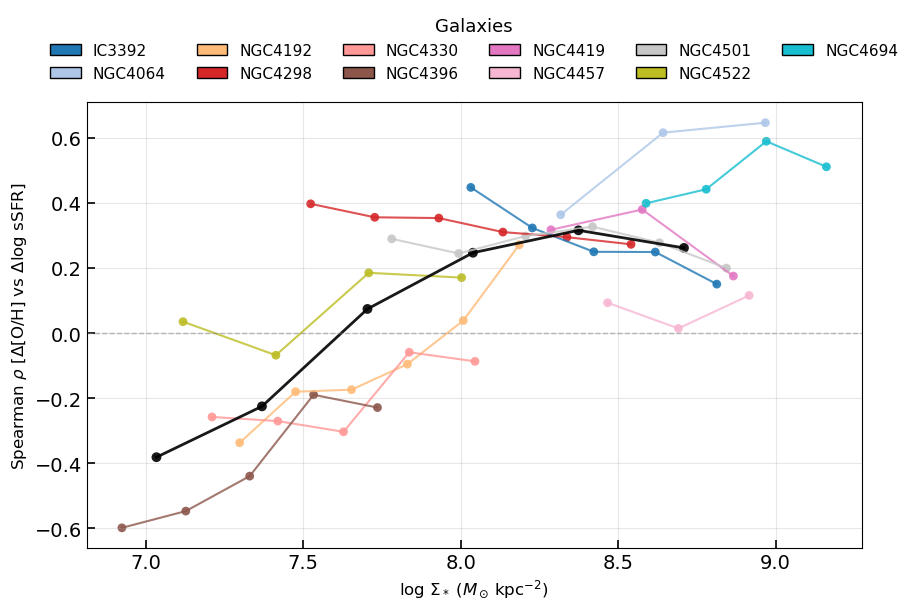

In [7]:
# ------------------------------------------------------------------
# Offset relations: Δ[O/H] vs Δlog sSFR in Σ_* bins
# For all galaxies (excluding NGC4383) and Spearman rho vs Σ_* summary
# Spearman rho uses only points inside 95% contour and only if trend exists
# ------------------------------------------------------------------
from pathlib import Path
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
import matplotlib.gridspec as gridspec
from scipy.stats import spearmanr
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# ------------------------------------------------------------------
# Helper: read the required maps
# ------------------------------------------------------------------
def load_maps(gal):
    spatial_path = f'{gal}_SPATIAL_BINNING_maps_extended.fits'
    gas_path = f'{gal}_gas_BIN_maps_extended.fits'

    if not (Path(spatial_path).exists() and Path(gas_path).exists()):
        raise FileNotFoundError(f'Required FITS files for {gal} not found.')

    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(gas_path) as h_gas:
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
        if 'O_H_O3N2_M14_HII' in h_gas:
            oh_map = h_gas['O_H_O3N2_M14_HII'].data
            indicator_name = 'O3N2-M14'
        elif 'O_H_O3N2_M13_HII' in h_gas:
            print(f"Warning: O3N2-M14 not available for {gal}; using O3N2-M13 instead.")
            oh_map = h_gas['O_H_O3N2_M13_HII'].data
            indicator_name = 'O3N2-M13'
        else:
            available = [hdu.name for hdu in h_gas]
            raise KeyError(f"No O3N2 metallicity extension (M14/M13) found for {gal}. Available: {available}")
    return sigM, sigSFR, oh_map, indicator_name

# ------------------------------------------------------------------
# Helper: calculate binned statistics with unique-count requirement
# ------------------------------------------------------------------
def calculate_binned_stats(x_data, y_data, bin_width=0.2, min_unique=20):
    """Calculate median and std in x-bins, requiring >= min_unique unique y values."""
    x_data = np.asarray(x_data)
    y_data = np.asarray(y_data)

    finite = np.isfinite(x_data) & np.isfinite(y_data)
    if np.sum(finite) == 0:
        return np.array([]), np.array([]), np.array([]), np.array([])

    x_min, x_max = np.nanmin(x_data[finite]), np.nanmax(x_data[finite])
    if not np.isfinite(x_min) or not np.isfinite(x_max) or x_min == x_max:
        return np.array([]), np.array([]), np.array([]), np.array([])

    bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
    if bin_edges.size < 2:
        return np.array([]), np.array([]), np.array([]), np.array([])

    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    medians = []
    stds = []
    counts = []
    valid_centers = []

    for i, (bin_start, bin_end) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
        in_bin = finite & (x_data >= bin_start) & (x_data < bin_end)
        if np.sum(in_bin) == 0:
            continue

        y_in_bin = y_data[in_bin]
        if len(np.unique(y_in_bin)) >= min_unique:
            medians.append(np.nanmedian(y_in_bin))
            stds.append(np.nanstd(y_in_bin))
            counts.append(len(y_in_bin))
            valid_centers.append(bin_centers[i])

    return (np.array(valid_centers), np.array(medians),
            np.array(stds), np.array(counts))

# ------------------------------------------------------------------
# Galaxy list and color map (reserve color for excluded galaxy)
# ------------------------------------------------------------------
all_bin_centers = []  # Σ_* bin centers for which rho is valid (per-galaxy)
all_rho_values = []   # Spearman rho (per-galaxy)
all_galaxy_indices = []

# Also store all spaxels across galaxies to compute a global trend
global_sigM_list = []
global_ssfr_list = []
global_oh_list = []
global_gal_index_list = []

# Build full galaxy list from available FITS files (including excluded)
bins = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies_all = [f.name.split('_')[0] for f in bins]
excluded_galaxies = {'NGC4383'}

# Build galaxy -> color mapping over ALL galaxies (so excluded keeps its color)
galaxy_colors_all = plt.cm.tab20(np.linspace(0, 1, len(galaxies_all)))
galaxy_color_dict = dict(zip(galaxies_all, galaxy_colors_all))

# Now define the working sample that EXCLUDES NGC4383 for analysis/plotting
galaxies = [g for g in galaxies_all if g not in excluded_galaxies]

print("=" * 80)
print(f"Offset relations and Spearman rho vs Σ_* (excluding: {excluded_galaxies})")
print("All galaxies (for color assignment):", ", ".join(galaxies_all))
print("Galaxies used in this analysis:", ", ".join(galaxies))
print("=" * 80)

# ------------------------------------------------------------------
# Loop over galaxies and compute Spearman rho per Σ_* bin (per-galaxy)
# and collect global spaxels for combined trend
# ------------------------------------------------------------------
for gal_index, gal in enumerate(galaxies):
    print(f"\nProcessing {gal} ...")
    try:
        sigM, sigSFR, oh_o3n2_map, indicator_name = load_maps(gal)
    except Exception as e:
        print(f"  Skipping {gal}: {e}")
        continue

    ssfr = sigSFR - sigM

    valid_ssfr = np.isfinite(ssfr)
    valid_oh = np.isfinite(oh_o3n2_map)
    valid_sigM = np.isfinite(sigM)
    valid_all = valid_ssfr & valid_oh & valid_sigM

    if np.sum(valid_all) == 0:
        print("  No valid pixels.")
        continue

    # Collect into global arrays for combined analysis
    global_sigM_list.append(sigM[valid_all].ravel())
    global_ssfr_list.append(ssfr[valid_all].ravel())
    global_oh_list.append(oh_o3n2_map[valid_all].ravel())
    global_gal_index_list.append(np.full(np.sum(valid_all), gal_index, dtype=int))

    # 1. Define 6 Σ_* bins for this galaxy (spanning 95% population)
    n_bins = 6
    sigmaM_min = np.nanpercentile(sigM[valid_all], 2.5)
    sigmaM_max = np.nanpercentile(sigM[valid_all], 97.5)
    sigmaM_bin_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins + 1)
    sigmaM_bin_centers = 0.5 * (sigmaM_bin_edges[:-1] + sigmaM_bin_edges[1:])

    # 2. Global symmetric limits for this galaxy (for reference / consistency)
    global_max_abs_ssfr = 0
    global_max_abs_oh = 0
    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
        else:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all

        if np.sum(bin_mask) > 0:
            ssfr_bin = ssfr[bin_mask]
            oh_bin = oh_o3n2_map[bin_mask]

            ssfr_offset = ssfr_bin - np.mean(ssfr_bin)
            oh_offset = oh_bin - np.mean(oh_bin)

            if np.any(np.isfinite(ssfr_offset)):
                global_max_abs_ssfr = max(global_max_abs_ssfr, np.nanmax(np.abs(ssfr_offset)))
            if np.any(np.isfinite(oh_offset)):
                global_max_abs_oh = max(global_max_abs_oh, np.nanmax(np.abs(oh_offset)))

    print(f"  Σ* range (95%): {sigmaM_min:.3f} to {sigmaM_max:.3f}")
    print(f"  Global Δlog(sSFR) axis limits: ±{global_max_abs_ssfr:.3f}")
    print(f"  Global Δ[O/H] axis limits: ±{global_max_abs_oh:.3f}")

    # 3. Compute Spearman rho in each Σ_* bin using 3-sigma clipping on unique data (per galaxy)
    print("  Spearman rho in each Σ_* bin (3σ clip + trend, per galaxy):")
    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
        else:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all

        n_pixels = np.sum(bin_mask)

        if n_pixels <= 0:
            print(f"    Bin {i+1:02d} ({sigmaM_bin_centers[i]:.2f}): n=0, r=N/A")
            continue

        # Values in this Σ_* bin
        ssfr_bin = ssfr[bin_mask]
        oh_bin = oh_o3n2_map[bin_mask]

        # Offsets within this bin
        ssfr_bin_mean = np.mean(ssfr_bin)
        oh_bin_mean = np.mean(oh_bin)

        ssfr_offset = ssfr_bin - ssfr_bin_mean
        oh_offset = oh_bin - oh_bin_mean

        valid_corr = np.isfinite(ssfr_offset) & np.isfinite(oh_offset)

        if np.sum(valid_corr) <= 2:
            spearman_rho = np.nan
            print(f"    Bin {i+1:02d} ({sigmaM_bin_centers[i]:.2f}): n={n_pixels}, r=N/A (insufficient valid points)")
            continue

        # ------------------------------------------------------------------
        # Calculate 3-sigma clipping mask on unique valid data
        # ------------------------------------------------------------------
        sigma_clip_mask = np.zeros_like(valid_corr, dtype=bool)
        if np.sum(valid_corr) > 0:
            # Get unique valid data using np.unique
            ssfr_data = ssfr_offset[valid_corr]
            oh_data = oh_offset[valid_corr]

            ssfr_unique = np.unique(ssfr_data)
            oh_unique = np.unique(oh_data)

            # Calculate mean and std on unique values
            x_mean = np.mean(ssfr_unique)
            x_std = np.std(ssfr_unique)
            y_mean = np.mean(oh_unique)
            y_std = np.std(oh_unique)

            # 3-sigma bounds
            x_lower = x_mean - 3 * x_std
            x_upper = x_mean + 3 * x_std
            y_lower = y_mean - 3 * y_std
            y_upper = y_mean + 3 * y_std

            # Apply 3-sigma clipping to all data points
            within_3sigma = (ssfr_data >= x_lower) & (ssfr_data <= x_upper) & \
                            (oh_data >= y_lower) & (oh_data <= y_upper)
            sigma_clip_mask[valid_corr] = within_3sigma

        # ------------------------------------------------------------------
        # Median trend using only points within 3-sigma
        # ------------------------------------------------------------------
        x_trend = ssfr_offset[sigma_clip_mask]
        y_trend = oh_offset[sigma_clip_mask]

        centers, medians, stds, counts = calculate_binned_stats(x_trend, y_trend,
                                                                 bin_width=0.2,
                                                                 min_unique=20)

        # Require at least 2 median-trend points for a valid trend
        has_trend = centers.size >= 2

        # ------------------------------------------------------------------
        # Spearman rho: only for points within 3-sigma and only if trend exists
        # ------------------------------------------------------------------
        if has_trend and np.sum(sigma_clip_mask & valid_corr) > 2:
            try:
                spearman_rho, spearman_p = spearmanr(ssfr_offset[sigma_clip_mask & valid_corr],
                                                     oh_offset[sigma_clip_mask & valid_corr])
                print(f"    Bin {i+1:02d} ({sigmaM_bin_centers[i]:.2f}): n={n_pixels}, r={spearman_rho:.3f} (p={spearman_p:.3g})")
            except Exception:
                spearman_rho = np.nan
                print(f"    Bin {i+1:02d} ({sigmaM_bin_centers[i]:.2f}): n={n_pixels}, r=N/A (error)")
        else:
            spearman_rho = np.nan
            print(f"    Bin {i+1:02d} ({sigmaM_bin_centers[i]:.2f}): n={n_pixels}, r=N/A (no trend or too few in 3σ)")

        # Store only valid rho values
        if np.isfinite(spearman_rho):
            all_bin_centers.append(sigmaM_bin_centers[i])
            all_rho_values.append(spearman_rho)
            all_galaxy_indices.append(gal_index)

# ------------------------------------------------------------------
# Prepare global arrays for combined Spearman vs Σ_* (all galaxies)
# ------------------------------------------------------------------
if global_sigM_list:
    global_sigM = np.concatenate(global_sigM_list)
    global_ssfr = np.concatenate(global_ssfr_list)
    global_oh = np.concatenate(global_oh_list)
else:
    global_sigM = np.array([])
    global_ssfr = np.array([])
    global_oh = np.array([])

# ------------------------------------------------------------------
# Convert collected per-galaxy Spearman rho data to arrays
# ------------------------------------------------------------------
all_bin_centers = np.array(all_bin_centers)
all_rho_values = np.array(all_rho_values)
all_galaxy_indices = np.array(all_galaxy_indices)

print("\n" + "=" * 80)
print("Summary: number of Σ_* bins with valid Spearman rho (per galaxy):", len(all_rho_values))
print("=" * 80)

# ------------------------------------------------------------------
# Compute combined Spearman rho vs Σ_* over all galaxies (same method)
# ------------------------------------------------------------------
global_bin_centers = []
global_rho_values = []

if global_sigM.size > 0:
    # Define 6 Σ_* bins for the combined sample (spanning 95% population)
    n_bins_global = 6
    sigmaM_min_g = np.nanpercentile(global_sigM, 2.5)
    sigmaM_max_g = np.nanpercentile(global_sigM, 97.5)
    sigmaM_edges_g = np.linspace(sigmaM_min_g, sigmaM_max_g, n_bins_global + 1)
    sigmaM_centers_g = 0.5 * (sigmaM_edges_g[:-1] + sigmaM_edges_g[1:])

    print("\nComputing combined Spearman rho in Σ_* bins (all galaxies together)...")
    for i in range(n_bins_global):
        if i == 0:
            bin_mask_g = (global_sigM >= sigmaM_edges_g[i]) & (global_sigM < sigmaM_edges_g[i+1])
        elif i == n_bins_global - 1:
            bin_mask_g = (global_sigM >= sigmaM_edges_g[i]) & (global_sigM <= sigmaM_edges_g[i+1])
        else:
            bin_mask_g = (global_sigM >= sigmaM_edges_g[i]) & (global_sigM < sigmaM_edges_g[i+1])

        n_pix_g = np.sum(bin_mask_g)
        if n_pix_g <= 0:
            print(f"  Global bin {i+1:02d} ({sigmaM_centers_g[i]:.2f}): n=0, r=N/A")
            continue

        ssfr_bin_g = global_ssfr[bin_mask_g]
        oh_bin_g = global_oh[bin_mask_g]

        ssfr_mean_g = np.mean(ssfr_bin_g)
        oh_mean_g = np.mean(oh_bin_g)

        ssfr_off_g = ssfr_bin_g - ssfr_mean_g
        oh_off_g = oh_bin_g - oh_mean_g

        valid_corr_g = np.isfinite(ssfr_off_g) & np.isfinite(oh_off_g)
        if np.sum(valid_corr_g) <= 2:
            print(f"  Global bin {i+1:02d} ({sigmaM_centers_g[i]:.2f}): n={n_pix_g}, r=N/A (insufficient valid points)")
            continue

        # ------------------------------------------------------------------
        # Calculate 3-sigma clipping mask on unique valid data (global)
        # ------------------------------------------------------------------
        sigma_clip_mask_global = np.zeros_like(valid_corr_g, dtype=bool)
        if np.sum(valid_corr_g) > 0:
            ssfr_data_g = ssfr_off_g[valid_corr_g]
            oh_data_g = oh_off_g[valid_corr_g]

            ssfr_unique_g = np.unique(ssfr_data_g)
            oh_unique_g = np.unique(oh_data_g)

            x_mean_g = np.mean(ssfr_unique_g)
            x_std_g = np.std(ssfr_unique_g)
            y_mean_g = np.mean(oh_unique_g)
            y_std_g = np.std(oh_unique_g)

            x_lower_g = x_mean_g - 3 * x_std_g
            x_upper_g = x_mean_g + 3 * x_std_g
            y_lower_g = y_mean_g - 3 * y_std_g
            y_upper_g = y_mean_g + 3 * y_std_g

            within_3sigma_g = (ssfr_data_g >= x_lower_g) & (ssfr_data_g <= x_upper_g) & \
                              (oh_data_g >= y_lower_g) & (oh_data_g <= y_upper_g)
            sigma_clip_mask_global[valid_corr_g] = within_3sigma_g

        x_trend_g = ssfr_off_g[sigma_clip_mask_global]
        y_trend_g = oh_off_g[sigma_clip_mask_global]

        centers_g, medians_g, stds_g, counts_g = calculate_binned_stats(x_trend_g, y_trend_g,
                                                                         bin_width=0.2,
                                                                         min_unique=20)

        has_trend_g = centers_g.size >= 3

        if has_trend_g and np.sum(sigma_clip_mask_global & valid_corr_g) > 2:
            try:
                rho_g, p_g = spearmanr(ssfr_off_g[sigma_clip_mask_global & valid_corr_g],
                                       oh_off_g[sigma_clip_mask_global & valid_corr_g])
                global_bin_centers.append(sigmaM_centers_g[i])
                global_rho_values.append(rho_g)
                print(f"  Global bin {i+1:02d} ({sigmaM_centers_g[i]:.2f}): n={n_pix_g}, r={rho_g:.3f} (p={p_g:.3g})")
            except Exception:
                print(f"  Global bin {i+1:02d} ({sigmaM_centers_g[i]:.2f}): n={n_pix_g}, r=N/A (error)")
        else:
            print(f"  Global bin {i+1:02d} ({sigmaM_centers_g[i]:.2f}): n={n_pix_g}, r=N/A (no trend or too few in 3σ)")

global_bin_centers = np.array(global_bin_centers)
global_rho_values = np.array(global_rho_values)

# ------------------------------------------------------------------
# Plot Spearman rho vs Σ_* for all galaxies, with galaxy color legend
# and an additional combined (all galaxies) trend in black
# ------------------------------------------------------------------
if len(all_rho_values) > 0:

    galaxy_indices_unique = np.unique(all_galaxy_indices)

    # Create figure with main axis and a thin top axis for legend
    fig = plt.figure(figsize=(10, 7))
    gs = gridspec.GridSpec(2, 1, height_ratios=[0.18, 1.0], hspace=0.05)
    legend_ax = fig.add_subplot(gs[0, 0])
    ax = fig.add_subplot(gs[1, 0])
    legend_ax.axis('off')

    plotted_galaxies = []  # Keep track of which galaxies are actually plotted

    # Plot Spearman rho vs Σ_* for each galaxy
    for idx in galaxy_indices_unique:
        mask = all_galaxy_indices == idx
        gal_name = galaxies[idx]
        color = galaxy_color_dict[gal_name]

        # Sort by Σ_* so lines are not scrambled
        x_vals = all_bin_centers[mask]
        y_vals = all_rho_values[mask]

        # Filter: skip if only 1 data point
        if len(x_vals) <= 1:
            continue

        plotted_galaxies.append(gal_name)

        order = np.argsort(x_vals)
        x_sorted = x_vals[order]
        y_sorted = y_vals[order]

        ax.plot(x_sorted, y_sorted, color=color, linewidth=1.5, alpha=0.8)
        ax.scatter(x_sorted, y_sorted, color=color, s=40, alpha=0.9, edgecolors='none', rasterized=True)

    # Add combined trend (all galaxies together) in black (no legend entry)
    if global_rho_values.size > 0:
        order_g = np.argsort(global_bin_centers)
        ax.plot(global_bin_centers[order_g], global_rho_values[order_g],
                color='black', linewidth=2.0, alpha=0.9, linestyle='-')
        ax.scatter(global_bin_centers[order_g], global_rho_values[order_g],
                   color='black', s=50, alpha=0.9, edgecolors='none', rasterized=True)

    # Axis formatting
    ax.axhline(0.0, color='gray', linestyle='--', linewidth=1.0, alpha=0.5)
    ax.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
    ax.set_ylabel(r'Spearman $\rho$ [Δ[O/H] vs Δ$\log\,\mathrm{sSFR}$]', fontsize=12)
    # ax.set_title(r'Spearman $\rho$ vs $\log\,\Sigma_*$ (all galaxies, excluding NGC4383)', fontsize=14)
    ax.grid(True, alpha=0.3)

    # ------------------------------------------------------------------
    # Galaxy legend at the top using dummy patches (excluding NGC4383)
    # ------------------------------------------------------------------
    legend_elements = [
        Patch(facecolor=galaxy_color_dict[gal], edgecolor='black', label=gal)
        for gal in plotted_galaxies
    ]
    if len(plotted_galaxies) > 0:
        legend_ax.legend(handles=legend_elements, loc='center', ncol=min(len(plotted_galaxies), 6),
                         frameon=False, fontsize=11, title='Galaxies', title_fontsize=13)

    plt.tight_layout()
    # plt.savefig('Plot_Paper_1/MAUVE_MUSE_SpearmanRho_vs_SigmaM_AllGalaxies_ExclNGC4383.png',
    #             dpi=600, bbox_inches='tight')
    # plt.savefig('Plot_Paper_1/MAUVE_MUSE_SpearmanRho_vs_SigmaM_AllGalaxies_ExclNGC4383.pdf',
    #             bbox_inches='tight')
    plt.show()
else:
    print("No valid Spearman rho values to plot.")